## Imports 

In [2]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import re
from textblob import TextBlob  # ספריה לניתוח רגשי
import seaborn as sns

## Part 1 - Data Loading and Exploratory Overview

In [5]:
df = pd.read_csv(
    r"C:\Users\user\OneDrive - Ariel University\תקייה מחשב ישן\שנה ג\סמסטר ב\למידת מכונה\פרוייקט\dataset.csv",
)
low_memory = False

C:\Users\user\AppData\Local\Temp\ipykernel_18584\3517229104.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [6]:
   def clean_and_count_words(text):
        if pd.isna(text):
            return 0
        text = str(text).lower()
        # מסיר כל תו שאינו אות, מספר או רווח
        clean_text = re.sub(r'[^a-z0-9\s]', '', text)
        return len(clean_text.split())

In [7]:
 def parse_categories(text):
        if pd.isna(text):
            return []
        text = str(text).lower().strip()
        if text in ["", "[]", "\\n", "unknown", "not found", "none"]:
            return []
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                items = parsed
            else:
                items = [text]
        except:
            items = re.split(r"\||/|,| and ", text)
            
        cleaned = []
        for item in items:
            item = str(item).strip()
            item = re.sub(r"\[.*?\]", "", item)
            item = re.sub(r"\(.*?\)", "", item)
            item = item.strip()
            if item and item not in ["unknown", "not found", "none"]:
                cleaned.append(item)
        return cleaned

In [8]:
def get_sentiment(text):
        if pd.isna(text) or str(text).strip() == "":
            return 0.0, 0.0
        blob = TextBlob(str(text))
        return blob.sentiment.polarity, blob.sentiment.subjectivity

In [9]:
def clean_target_variable(df):

    df = df.copy()

    if 'averageRating' in df.columns:

        df['averageRating'] = pd.to_numeric(
            df['averageRating'],
            errors='coerce'
        )

        df = df[
            (df['averageRating'] >= 1.0) &
            (df['averageRating'] <= 10.0)
        ]

    return df

In [10]:
def normalize_column_names(df):

    df = df.copy()

    for col in df.columns:

        if col.lower() == 'genres' and col != 'genres':

            df = df.rename(
                columns={col: 'genres'}
            )

    return df

In [11]:
def fill_basic_missing_values(df):

    df = df.copy()

    fill_values = {
        'Country': 'Unknown',
        'Language': 'Unknown',
        'plot': '',
        'genres': 'Unknown',
        'primaryTitle': 'Unknown'
    }

    for col, value in fill_values.items():

        if col in df.columns:

            df[col] = df[col].fillna(value)

    if 'lead_actors_ids' in df.columns:

        df['lead_actors_ids'] = (
            df['lead_actors_ids']
            .apply(
                lambda x: [] if pd.isna(x) else x
            )
        )

    return df

In [12]:
def create_plot_features(df):

    df = df.copy()

    if 'plot' in df.columns:

        df['plot_word_count'] = (
            df['plot']
            .apply(clean_and_count_words)
        )

        sentiments = (
            df['plot']
            .apply(get_sentiment)
        )

        df['plot_polarity'] = [
            s[0] for s in sentiments
        ]

        df['plot_subjectivity'] = [
            s[1] for s in sentiments
        ]

    return df

In [13]:
def create_decade_feature(df):

    df = df.copy()

    if 'startYear' in df.columns:

        df['startYear'] = pd.to_numeric(
            df['startYear'],
            errors='coerce'
        )

        df.loc[
            (
                (df['startYear'] < 1874) |
                (df['startYear'] > 2030)
            ),
            'startYear'
        ] = np.nan

        df['decade'] = (
            (df['startYear'] // 10) * 10
        )

        df['decade'] = (
            df['decade']
            .fillna(0)
        )

    return df

In [14]:
def count_lead_actors(value):

    if isinstance(value, list):
        return len(value)

    text = str(value).strip()

    invalid_values = [
        '',
        '[]',
        '\\N',
        'nan',
        'None'
    ]

    if text in invalid_values:
        return 0

    try:

        parsed = ast.literal_eval(text)

        if isinstance(parsed, list):
            return len(parsed)

    except:
        pass

    if ',' in text:

        return len([
            i for i in text.split(',')
            if i.strip() != ''
        ])

    if ' ' in text:

        return len([
            i for i in text.split()
            if i.strip() != ''
        ])

    return 0

In [15]:
def create_lead_actors_feature(df):

    df = df.copy()

    if 'lead_actors_ids' in df.columns:

        df['num_lead_actors'] = (
            df['lead_actors_ids']
            .apply(count_lead_actors)
        )

    return df

In [16]:
def count_genres(value):

    if isinstance(value, list):
        return len(value)

    text = str(value).strip()

    invalid_values = [
        '',
        '[]',
        '\\N',
        'Unknown'
    ]

    if text in invalid_values:
        return 0

    try:

        parsed = ast.literal_eval(text)

        if isinstance(parsed, list):
            return len(parsed)

    except:
        pass

    if ',' in text:

        split_values = [
            item.strip()
            for item in text.split(',')
            if item.strip() != ''
        ]

        return len(split_values)

    if ' ' in text:

        split_values = [
            item.strip()
            for item in text.split()
            if item.strip() != ''
        ]

        return len(split_values)

    return 1

In [17]:
def create_genres_count_feature(df):

    df = df.copy()

    if 'genres' in df.columns:

        df['num_genres'] = (
            df['genres']
            .apply(count_genres)
        )

    return df

In [18]:
def create_parsed_category_columns(df):

    df = df.copy()

    if 'Country' in df.columns:
        df['Country_parsed'] = (
            df['Country']
            .apply(parse_multilabel_categories)
        )

    if 'Language' in df.columns:
        df['Language_parsed'] = (
            df['Language']
            .apply(parse_multilabel_categories)
        )

    if 'genres' in df.columns:
        df['genres_parsed'] = (
            df['genres']
            .apply(parse_multilabel_categories)
        )

    return df

In [19]:
def get_top_category_lists(df, top_lists=None):

    if top_lists is None:

        top_countries = (
            df['Country_parsed']
            .explode()
            .value_counts()
            .head(10)
            .index
            .tolist()
        )

        top_languages = (
            df['Language_parsed']
            .explode()
            .value_counts()
            .head(10)
            .index
            .tolist()
        )

        top_genres = (
            df['genres_parsed']
            .explode()
            .value_counts()
            .head(12)
            .index
            .tolist()
        )

        current_top_lists = {
            'countries': top_countries,
            'languages': top_languages,
            'genres': top_genres
        }

    else:

        current_top_lists = top_lists

    return current_top_lists

In [20]:
def create_country_features(df, top_countries):

    df = df.copy()

    if 'Country_parsed' in df.columns:

        created_country_cols = []

        for country in top_countries:

            col_name = f"In_{country.replace('-', '_').replace(' ', '_').title()}"

            created_country_cols.append(col_name)

            df[col_name] = df['Country_parsed'].apply(
                lambda x: 1 if isinstance(x, list) and country in x else 0
            )

        if created_country_cols:

            df['In_Other_Country'] = (
                df[created_country_cols]
                .sum(axis=1)
                .eq(0)
                .astype(int)
            )

        df = df.drop(columns=['Country_parsed'])

    return df

In [21]:
def create_language_features(df, top_languages):

    df = df.copy()

    if 'Language_parsed' in df.columns:

        for lang in top_languages:

            col_name = f"is_lang_{lang.replace('-', '_').replace(' ', '_')}"

            df[col_name] = df['Language_parsed'].apply(
                lambda x: 1 if isinstance(x, list) and lang in x else 0
            )

        df = df.drop(columns=['Language_parsed'])

    return df

In [22]:
def create_genre_features(df, top_genres):

    df = df.copy()

    if 'genres_parsed' in df.columns:

        created_genre_cols = []

        for genre in top_genres:

            col_name = (
                f"is_genre_{genre.replace('-', '_').replace(' ', '_')}"
            )

            created_genre_cols.append(col_name)

            df[col_name] = (
                df['genres_parsed']
                .apply(
                    lambda x: 1 if isinstance(x, list) and genre in x else 0
                )
                * df['decade']
            )

        if created_genre_cols:

            df['is_genre_other'] = (
                (
                    df[created_genre_cols]
                    .sum(axis=1)
                    == 0
                )
                .astype(int)
                * df['decade']
            )

        df = df.drop(columns=['genres_parsed'])

    return df

In [23]:
def runtime_category(runtime):

    if pd.isna(runtime):
        return 'Unknown'

    if runtime < 60:
        return 'Short'

    elif runtime <= 120:
        return 'Standard'

    else:
        return 'Long'

In [24]:
def create_parsed_category_columns(df):

    df = df.copy()

    if 'Country' in df.columns:
        df['Country_parsed'] = df['Country'].apply(parse_categories)

    if 'Language' in df.columns:
        df['Language_parsed'] = df['Language'].apply(parse_categories)

    if 'genres' in df.columns:
        df['genres_parsed'] = df['genres'].apply(parse_categories)

    return df

## Final prepare_data

In [26]:
def prepare_data(df, top_lists=None):

    df_clean = df.copy()

    # ניקוי בסיסי
    df_clean = clean_target_variable(df_clean)
    df_clean = normalize_column_names(df_clean)
    df_clean = fill_basic_missing_values(df_clean)

    # Feature Engineering
    df_clean = create_plot_features(df_clean)
    df_clean = create_decade_feature(df_clean)

    if 'lead_actors_ids' in df_clean.columns:
        df_clean['num_lead_actors'] = (
            df_clean['lead_actors_ids']
            .apply(count_lead_actors)
        )

    df_clean = create_genres_count_feature(df_clean)

    # Multi Label Features
    df_clean = create_parsed_category_columns(df_clean)

    current_top_lists = get_top_category_lists(
        df_clean,
        top_lists=top_lists
    )

    top_countries = current_top_lists['countries']
    top_languages = current_top_lists['languages']
    top_genres = current_top_lists['genres']

    df_clean = create_country_features(df_clean, top_countries)
    df_clean = create_language_features(df_clean, top_languages)
    df_clean = create_genre_features(df_clean, top_genres)

    # Runtime Features
    if 'runtimeMinutes' in df_clean.columns:

        df_clean['runtimeMinutes'] = pd.to_numeric(
            df_clean['runtimeMinutes'],
            errors='coerce'
        )

        df_clean.loc[
            (df_clean['runtimeMinutes'] <= 0) |
            (df_clean['runtimeMinutes'] > 420),
            'runtimeMinutes'
        ] = np.nan

        df_clean['runtime_category'] = (
            df_clean['runtimeMinutes']
            .apply(runtime_category)
        )


    return df_clean, current_top_lists

In [27]:
# מריצים את הפונקציה ומפרקים את שני האיברים שהיא מחזירה
# המשתנה df_prepared יקבל את ה-DataFrame כרגיל, ומשתנה העזר יקבל את הרשימות של האימון הכללי
df_prepared, general_train_lists = prepare_data(df)


<div style="background-color:#d4edda; 
            padding:12px; 
            border-radius:8px; 
            border:1px solid #c3e6cb;
            color:#155724;
            font-weight:bold;
            text-align:center;">

✅ The dataset has been successfully cleaned, transformed, and prepared for machine learning modeling.

</div>

## Feature Analysis: Variance and Correlation Checks

In [30]:
# Variances for each of our Features and Modeling Data
variance = (
    df_prepared
    .var(numeric_only=True)
    .sort_values()
)

variance

In_Hong_Kong            6.567632e-03
In_Spain                7.966041e-03
is_lang_malayalam       8.366062e-03
In_Germany              8.502164e-03
is_lang_telugu          8.748751e-03
is_lang_tamil           1.017478e-02
is_lang_german          1.089467e-02
In_Canada               1.189225e-02
is_lang_japanese        1.320789e-02
In_Japan                1.336788e-02
plot_polarity           1.588773e-02
is_lang_italian         1.628027e-02
In_Italy                1.678203e-02
is_lang_spanish         1.817574e-02
In_France               2.003859e-02
is_lang_hindi           2.016307e-02
is_lang_french          2.129839e-02
In_United_Kingdom       2.681022e-02
In_India                5.574808e-02
plot_subjectivity       5.609894e-02
In_United_States        1.425913e-01
is_lang_english         1.784976e-01
In_Other_Country        2.216442e-01
num_genres              7.276323e-01
averageRating           1.671334e+00
num_lead_actors         2.362094e+00
runtimeMinutes          4.993860e+02
s

In [31]:
# Set a correlletion table between the features 
corr_matrix = df_prepared.corr(numeric_only=True)

corr_matrix

,startYear,runtimeMinutes,averageRating,numVotes,BoxOffice,plot_word_count,plot_polarity,plot_subjectivity,decade,num_lead_actors,...,is_genre_action,is_genre_documentary,is_genre_crime,is_genre_thriller,is_genre_horror,is_genre_adventure,is_genre_mystery,is_genre_family,is_genre_fantasy,is_genre_other
startYear,1.000000,0.134172,-0.032772,0.037387,0.009314,-0.025184,-0.026805,-0.042860,0.993408,-0.199587,...,0.023895,0.195340,-0.065879,0.115259,0.098805,-0.055282,0.017701,0.016991,0.016379,-0.048304
runtimeMinutes,0.134172,1.000000,0.155416,0.118692,0.000839,0.100927,0.053585,0.110662,0.129749,0.149954,...,0.140117,-0.152111,0.025993,0.026719,-0.094199,-0.013039,0.000762,-0.006391,0.001482,-0.029273
averageRating,-0.032772,0.155416,1.000000,0.107823,0.012889,0.055945,0.041643,0.021209,-0.031070,-0.253050,...,-0.106703,0.296653,-0.015004,-0.136356,-0.275007,-0.041471,-0.047078,0.006882,-0.046804,0.003330
numVotes,0.037387,0.118692,0.107823,1.000000,-0.003068,0.249496,0.001726,0.113172,0.036103,0.054780,...,0.091235,-0.046582,0.041112,0.033190,0.007247,0.112166,0.039354,0.002307,0.043719,-0.024388
BoxOffice,0.009314,0.000839,0.012889,-0.003068,1.000000,-0.005702,-0.005620,0.011766,0.007512,-0.009398,...,-0.005186,0.005342,-0.005733,-0.005955,-0.004883,-0.002966,-0.004044,-0.003490,-0.003278,-0.001781
plot_word_count,-0.025184,0.100927,0.055945,0.249496,-0.005702,1.000000,0.076978,0.313879,-0.024266,0.088211,...,0.059096,-0.073681,0.040571,0.036667,0.037483,0.073683,0.050967,0.006261,0.039937,-0.036788
plot_polarity,-0.026805,0.053585,0.041643,0.001726,-0.005620,0.076978,1.000000,0.242853,-0.026023,0.006993,...,-0.030140,-0.008623,-0.040423,-0.046976,-0.066091,-0.004257,-0.026487,0.018078,0.001769,-0.001181
plot_subjectivity,-0.042860,0.110662,0.021209,0.113172,0.011766,0.313879,0.242853,1.000000,-0.041133,0.119747,...,0.047465,-0.115155,0.051819,0.040664,0.024102,0.043007,0.043789,0.011139,0.032281,-0.053070
decade,0.993408,0.129749,-0.031070,0.036103,0.007512,-0.024266,-0.026023,-0.041133,1.000000,-0.193446,...,0.023055,0.189336,-0.063229,0.112398,0.096187,-0.053119,0.017237,0.016810,0.016192,-0.046727
num_lead_actors,-0.199587,0.149954,-0.253050,0.054780,-0.009398,0.088211,0.006993,0.119747,-0.193446,1.000000,...,0.128005,-0.797969,0.106741,0.104823,0.075062,0.073173,0.066012,0.036866,0.055177,-0.018480


#### HeatMap for correletion between Features

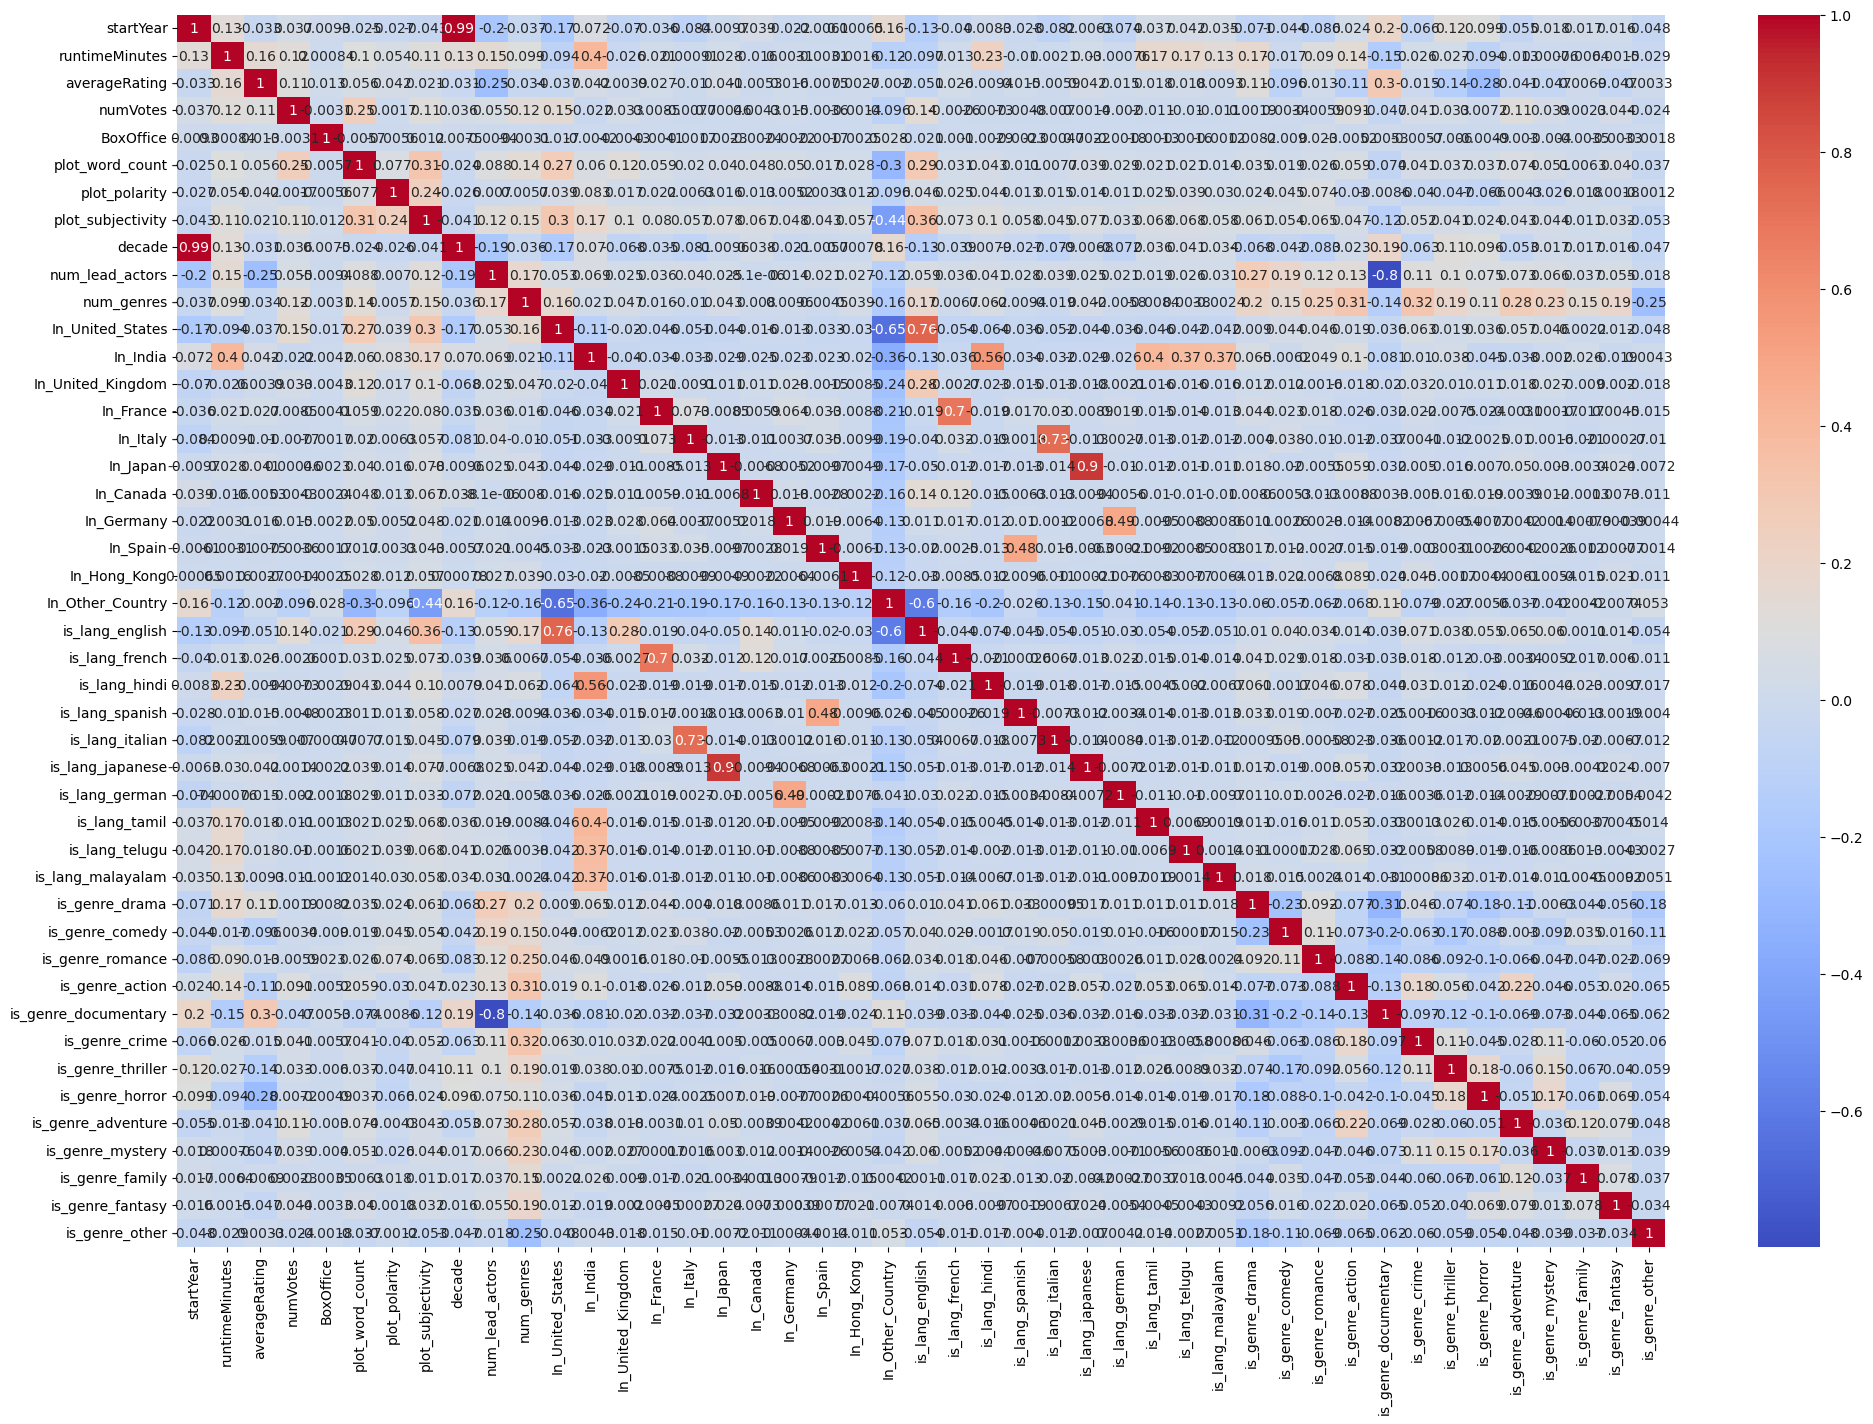

In [33]:
import seaborn as sns
plt.figure(figsize=(24,16))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Models

#### Compiling and Training our model
#### Check our indicators

In [292]:
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import ElasticNet

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter


In [37]:
# עמודות שרוצים לשמור ב-df אבל לא להכניס למודל
columns_to_exclude = [
    'tconst',
    'primaryTitle',
    'startYear',
    'genres',
    'num_genres',
    'lead_actors_ids',
    'Language',
    'Country',
    'plot',
    'budget',
    'averageRating',
    'numVotes',
    'BoxOffice'
]

In [38]:
# שלב 1: פיצול הדאטה הגולמי
df_train_raw, df_test_raw = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

# שלב 2: הרצת prepare_data על ה-Train בלבד
df_train_prepared, trained_top_lists = prepare_data(df_train_raw)


df_test_prepared_en, _ = prepare_data(
    df_test_raw,
    top_lists=trained_top_lists
)

In [39]:
# שלב 3: הפרדת X ו-y
X_train = df_train_prepared.drop(
    columns=columns_to_exclude,
    errors='ignore'
)

y_train = df_train_prepared['averageRating']

In [40]:
# שלב 3: בניית ה-Pipeline הסטנדרטי
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer, ['runtime_category'])
    ],
    remainder='drop'
)

In [41]:
en_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(random_state=42, max_iter=10000))
])

param_grid_en = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
    'regressor__l1_ratio': [0.2, 0.5, 0.8]
}

grid_search_en = GridSearchCV(
    estimator=en_pipeline, param_grid=param_grid_en, cv=10,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    refit='neg_root_mean_squared_error', n_jobs=-1
)

In [42]:
# שלב 4: אימון המודל על ה-Train
print("Starting Elastic Net model training...")
grid_search_en.fit(X_train, y_train)
print("Elastic Net Fitted Successfully !\n")

Starting Elastic Net model training...
Elastic Net Fitted Successfully !



In [43]:
print("=" * 60)
print(" " * 8 + "10-Fold Cross Validation Report - Elastic Net")
print("=" * 60)

print(f"{'Metric':<15} | {'Mean':<12} | {'Std':<12}")
print("-" * 60)

print(
    f"{'R^2 Score':<15} | "
    f"{grid_search_en.cv_results_['mean_test_r2'][grid_search_en.best_index_]:<12.4f} | "
    f"{grid_search_en.cv_results_['std_test_r2'][grid_search_en.best_index_]:<12.4f}"
)

print(
    f"{'RMSE':<15} | "
    f"{-grid_search_en.cv_results_['mean_test_neg_root_mean_squared_error'][grid_search_en.best_index_]:<12.4f} | "
    f"{grid_search_en.cv_results_['std_test_neg_root_mean_squared_error'][grid_search_en.best_index_]:<12.4f}"
)

print(
    f"{'MAE':<15} | "
    f"{-grid_search_en.cv_results_['mean_test_neg_mean_absolute_error'][grid_search_en.best_index_]:<12.4f} | "
    f"{grid_search_en.cv_results_['std_test_neg_mean_absolute_error'][grid_search_en.best_index_]:<12.4f}"
)

print("=" * 60)

        10-Fold Cross Validation Report - Elastic Net
Metric          | Mean         | Std         
------------------------------------------------------------
R^2 Score       | 0.2346       | 0.0058      
RMSE            | 1.1286       | 0.0102      
MAE             | 0.8636       | 0.0087      


In [44]:
# שלב 5: הכנת נתוני הטסט על בסיס הרשימות שנלמדו מהאימון (0% זליגה!)
X_test_clean, _ = prepare_data(
    df_test_raw,
    top_lists=trained_top_lists
)

X_test = X_test_clean.drop(
    columns=columns_to_exclude,
    errors='ignore'
)

y_test = X_test_clean['averageRating']

In [45]:
# שלב 6: חישוב והדפסת המדדים ישירות (במקום הפונקציה שקרסה)
y_pred_en = grid_search_en.predict(X_test)

test_rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
test_mae_en = mean_absolute_error(y_test, y_pred_en)
test_r2_en = r2_score(y_test, y_pred_en)

In [46]:
print("=" * 50)
print("Performance Metrics for Elastic Net")
print("=" * 50)

print(f"R^2 Score: {test_r2_en:.4f}")
print(f"RMSE: {test_rmse_en:.4f}")
print(f"MAE: {test_mae_en:.4f}")

print("=" * 50)

Performance Metrics for Elastic Net
R^2 Score: 0.2405
RMSE: 1.1360
MAE: 0.8726


In [47]:
# חיזויים עבור מודל Elastic Net
y_train_pred_en = grid_search_en.predict(X_train)
y_test_pred_en = grid_search_en.predict(X_test)

In [48]:
# חישוב מדדי אימון (Train)
train_rmse_en = np.sqrt(mean_squared_error(y_train, y_train_pred_en))
train_mae_en = mean_absolute_error(y_train, y_train_pred_en)
train_r2_en = r2_score(y_train, y_train_pred_en)

In [49]:
# חישוב מדדי בחירה (Test)
test_rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
test_mae_en = mean_absolute_error(y_test, y_pred_en)
test_r2_en = r2_score(y_test, y_pred_en)

In [50]:
# Print formatted Train vs Test comparison report
print("=" * 60)
print(" " * 10 + "Train vs Test Performance Report - Elastic Net")
print("=" * 60)

print(f"{'Metric':<15} | {'Train Set':<12} | {'Test Set':<12} | {'Gap':<12}")

print("-" * 60)

print(f"{'R^2 Score':<15} | {train_r2_en:<12.4f} | {test_r2_en:<12.4f} | {train_r2_en - test_r2_en:<12.4f}")

print(f"{'RMSE':<15} | {train_rmse_en:<12.4f} | {test_rmse_en:<12.4f} | {test_rmse_en - train_rmse_en:<12.4f}")

print(f"{'MAE':<15} | {train_mae_en:<12.4f} | {test_mae_en:<12.4f} | {test_mae_en - train_mae_en:<12.4f}")

print("=" * 60)

          Train vs Test Performance Report - Elastic Net
Metric          | Train Set    | Test Set     | Gap         
------------------------------------------------------------
R^2 Score       | 0.2354       | 0.2405       | -0.0051     
RMSE            | 1.1281       | 1.1360       | 0.0079      
MAE             | 0.8632       | 0.8726       | 0.0094      


### Extracting outliers Elastic Net

In [51]:
# חילוץ האאוטליירים של Elastic Net

# יצירת טבלת ניתוח שגיאות
elastic_net_full_error_prediction = X_test_clean.copy()

elastic_net_full_error_prediction['actual_rating'] = y_test
elastic_net_full_error_prediction['predicted_rating'] = y_pred_en

# חישוב שגיאה
elastic_net_full_error_prediction['prediction_error'] = (
    elastic_net_full_error_prediction['actual_rating']
    - elastic_net_full_error_prediction['predicted_rating']
)

# 10 הסרטים שבהם המודל העריך נמוך מדי
top_10_elastic_net_over_idx = (
    elastic_net_full_error_prediction
    .sort_values(by='prediction_error', ascending=False)
    .head(10)
    .index
)

# 10 הסרטים שבהם המודל העריך גבוה מדי
top_10_elastic_net_under_idx = (
    elastic_net_full_error_prediction
    .sort_values(by='prediction_error', ascending=True)
    .head(10)
    .index
)

# סימון סוג החריג
elastic_net_full_error_prediction['outlier_type'] = 'Normal'

elastic_net_full_error_prediction.loc[
    top_10_elastic_net_over_idx,
    'outlier_type'
] = 'Top 10 Overprediction'

elastic_net_full_error_prediction.loc[
    top_10_elastic_net_under_idx,
    'outlier_type'
] = 'Top 10 Underprediction'

# הוספת שם הסרט
if 'primaryTitle' in df_test_raw.columns:
    elastic_net_full_error_prediction['primaryTitle'] = df_test_raw.loc[
        elastic_net_full_error_prediction.index,
        'primaryTitle'
    ]

# שמירת 20 החריגים בלבד
df_outliers_elastic_net = elastic_net_full_error_prediction[
    elastic_net_full_error_prediction['outlier_type'] != 'Normal'
].copy()

# תצוגה
display(
    df_outliers_elastic_net[
        [
            'primaryTitle',
            'actual_rating',
            'predicted_rating',
            'prediction_error',
            'outlier_type'
        ]
    ].sort_values('prediction_error', ascending=False)
)

,primaryTitle,actual_rating,predicted_rating,prediction_error,outlier_type
122164,Gray Shadows,9.6,5.577061,4.022939,Top 10 Overprediction
106740,Buried in Tucson,9.8,5.839850,3.960150,Top 10 Overprediction
130302,"Hey Monster, Hands Off My City",8.7,4.748791,3.951209,Top 10 Overprediction
22978,Moksha,8.9,4.983041,3.916959,Top 10 Overprediction
97529,An Inappropriate Affect,8.8,4.902749,3.897251,Top 10 Overprediction
33879,Natural Demise,8.5,4.602985,3.897015,Top 10 Overprediction
121147,Hidden Agenda,9.6,5.708048,3.891952,Top 10 Overprediction
98017,Apoteose,9.8,5.963142,3.836858,Top 10 Overprediction
267,I Want You to Panic!,9.0,5.306103,3.693897,Top 10 Overprediction
130279,Getting Even,9.6,5.917999,3.682001,Top 10 Overprediction


In [52]:
# רנדום מפה

In [53]:
# שלב 1: הכנת נתוני הטסט עבור ה-Random Forest באמצעות הרשימות שנוצרו מתא 21
df_test_prepared_rf, _ = prepare_data(
    df_test_raw,
    top_lists=trained_top_lists
)

X_test_rf = df_test_prepared_rf.drop(
    columns=columns_to_exclude,
    errors='ignore'
)

y_test_rf = df_test_prepared_rf['averageRating']

In [54]:
# שלב 2: בניית ה-Pipeline עבור Random Forest (בתוך ה-Cross Validation)
numeric_transformer_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_rf, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer_rf, ['runtime_category'])
    ],
    remainder='drop'
)

In [55]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [56]:
# שלב 3: הגדרת גריד הפרמטרים ואימון עם 10-Fold CV
param_grid_rf = {
    'regressor__n_estimators': [400],
    'regressor__max_depth': [12],
    'regressor__min_samples_leaf': [8]
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=10,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    refit='neg_root_mean_squared_error',
    n_jobs=-1
)

In [57]:
print("Starting Random Forest model training with 10-Fold Cross Validation...")
# משתמשים בנתוני ה-Train המבודדים והמוכנים שכבר חולצו בתא 21
grid_search_rf.fit(X_train, y_train)
print("Random Forest training completed successfully !\n")

Starting Random Forest model training with 10-Fold Cross Validation...
Random Forest training completed successfully !



In [58]:
print("=" * 60)
print(" " * 8 + "10-Fold Cross Validation Report - Random Forest")
print("=" * 60)

print(f"{'Metric':<15} | {'Mean':<12} | {'Std':<12}")

print("-" * 60)

print(
    f"{'R^2 Score':<15} | "
    f"{grid_search_rf.cv_results_['mean_test_r2'][grid_search_rf.best_index_]:<12.4f} | "
    f"{grid_search_rf.cv_results_['std_test_r2'][grid_search_rf.best_index_]:<12.4f}"
)

print(
    f"{'RMSE':<15} | "
    f"{-grid_search_rf.cv_results_['mean_test_neg_root_mean_squared_error'][grid_search_rf.best_index_]:<12.4f} | "
    f"{grid_search_rf.cv_results_['std_test_neg_root_mean_squared_error'][grid_search_rf.best_index_]:<12.4f}"
)

print(
    f"{'MAE':<15} | "
    f"{-grid_search_rf.cv_results_['mean_test_neg_mean_absolute_error'][grid_search_rf.best_index_]:<12.4f} | "
    f"{grid_search_rf.cv_results_['std_test_neg_mean_absolute_error'][grid_search_rf.best_index_]:<12.4f}"
)

print("=" * 60)

        10-Fold Cross Validation Report - Random Forest
Metric          | Mean         | Std         
------------------------------------------------------------
R^2 Score       | 0.2682       | 0.0083      
RMSE            | 1.1035       | 0.0083      
MAE             | 0.8397       | 0.0079      


In [59]:
# שלב 4: חישוב והדפסת המדדים ישירות (במקום הפונקציה שקרסה)
y_pred_rf = grid_search_rf.predict(X_test_rf)

test_rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
test_mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
test_r2_rf = r2_score(y_test_rf, y_pred_rf)

In [60]:
print("=" * 50)
print("Performance Metrics for Random Forest")
print("=" * 50)

print(f"R^2 Score: {test_r2_rf:.4f}")
print(f"RMSE: {test_rmse_rf:.4f}")
print(f"MAE: {test_mae_rf:.4f}")

print("=" * 50)

Performance Metrics for Random Forest
R^2 Score: 0.2750
RMSE: 1.1099
MAE: 0.8477


In [61]:
# חיזויים עבור מודל Random Forest
y_train_pred_rf = grid_search_rf.predict(X_train)
y_test_pred_rf = grid_search_rf.predict(X_test_rf)

In [62]:
# חישוב מדדי אימון (Train)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)

In [63]:
# חישוב מדדי בחירה (Test)
test_rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
test_mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
test_r2_rf = r2_score(y_test_rf, y_pred_rf)

In [64]:
# Print formatted Train vs Test comparison report
print("=" * 60)
print(" " * 10 + "Train vs Test Performance Report - Random Forest")
print("=" * 60)

print(f"{'Metric':<15} | {'Train Set':<12} | {'Test Set':<12} | {'Gap':<12}")

print("-" * 60)

print(f"{'R^2 Score':<15} | {train_r2_rf:<12.4f} | {test_r2_rf:<12.4f} | {train_r2_rf - test_r2_rf:<12.4f}")

print(f"{'RMSE':<15} | {train_rmse_rf:<12.4f} | {test_rmse_rf:<12.4f} | {test_rmse_rf - train_rmse_rf:<12.4f}")

print(f"{'MAE':<15} | {train_mae_rf:<12.4f} | {test_mae_rf:<12.4f} | {test_mae_rf - train_mae_rf:<12.4f}")

print("=" * 60)

          Train vs Test Performance Report - Random Forest
Metric          | Train Set    | Test Set     | Gap         
------------------------------------------------------------
R^2 Score       | 0.3126       | 0.2750       | 0.0376      
RMSE            | 1.0696       | 1.1099       | 0.0402      
MAE             | 0.8124       | 0.8477       | 0.0353      


## Erorr Analysis

In [66]:
# 5.1 

In [67]:
# הפעם ניקח את השמות מתוך df_test_prepared_rf שמותאם בגודלו לתחזיות
error_analysis_df = pd.DataFrame({
    'Movie Title': df_test_prepared_rf['primaryTitle'], # <--- התיקון כאן
    'Actual Rating': y_test_rf,
    'Predicted Rating': y_pred_rf
})

In [68]:
# חישוב שגיאת החיזוי
error_analysis_df['Prediction Error'] = error_analysis_df['Predicted Rating'] - error_analysis_df['Actual Rating']

# חילוץ 10 הסרטים עם ה-Overprediction הגדול ביותר
top_10_overpredicted = error_analysis_df.nlargest(10, 'Prediction Error')

# חילוץ 10 הסרטים עם ה-Underprediction הגדול ביותר
top_10_underpredicted = error_analysis_df.nsmallest(10, 'Prediction Error')

In [69]:
# הדפסת התוצאות
print("=" * 60)
print("Top 10 Overpredictions (Model predicted much HIGHER than actual)")
print("=" * 60)
display(top_10_overpredicted[['Movie Title', 'Actual Rating', 'Predicted Rating', 'Prediction Error']])

print("\n" + "=" * 60)
print("Top 10 Underpredictions (Model predicted much LOWER than actual)")
print("=" * 60)
display(top_10_underpredicted[['Movie Title', 'Actual Rating', 'Predicted Rating', 'Prediction Error']])

Top 10 Overpredictions (Model predicted much HIGHER than actual)


,Movie Title,Actual Rating,Predicted Rating,Prediction Error
16815,Kurz,1.2,7.200055,6.000055
10554,Jasenovac: Istina,1.4,7.072613,5.672613
90191,Amazing China,1.8,7.186168,5.386168
48587,Proud American,1.1,6.447143,5.347143
47899,Pure Hearts: Into Chinese Showbiz,1.0,6.253743,5.253743
125768,Ghadaar,1.8,6.682004,4.882004
48832,Roofied: A Double Dose,1.2,6.043783,4.843783
70735,After Party,1.3,6.135845,4.835845
28622,Nomad & Roadrunner,1.9,6.681262,4.781262
65130,Akin ka ngayong gabi,1.3,6.071098,4.771098



Top 10 Underpredictions (Model predicted much LOWER than actual)


,Movie Title,Actual Rating,Predicted Rating,Prediction Error
130302,"Hey Monster, Hands Off My City",8.7,4.519305,-4.180695
121034,Good Intentions,9.4,5.387232,-4.012768
33879,Natural Demise,8.5,4.488998,-4.011002
97529,An Inappropriate Affect,8.8,4.876356,-3.923644
106740,Buried in Tucson,9.8,5.930159,-3.869841
122164,Gray Shadows,9.6,5.806444,-3.793556
74731,Tomato Man,7.9,4.168622,-3.731378
5381,Ingili,8.7,4.979497,-3.720503
120369,Good Villain,9.1,5.450593,-3.649407
108977,Cabezas Encogidas,8.8,5.165908,-3.634092


In [70]:
# 5.2 ניתוח איכותי

In [71]:
# 5.2.1

In [72]:
df = df_prepared

In [73]:
# 1. איחוד שתי רשימות החריגים לטבלה אחת של 20 סרטים
outliers_combined = pd.concat([top_10_overpredicted, top_10_underpredicted])

# --- אפשרות א': סינון לפי שם הסרט ---
# בהנחה ששם הסרט ב-df המקורי נמצא בעמודה 'primaryTitle' (שנה אם זה שונה אצלך)
outlier_titles = outliers_combined['Movie Title']

# החלף את 'df' בשם המשתנה של הדאטה-פריים המלא שלך (למשל df_test_raw או df_movies)
df_outliers_full_data = df[df['primaryTitle'].isin(outlier_titles)]


# --- אפשרות ב': סינון לפי האינדקס (מומלץ ובטוח יותר) ---
# אם ה-DataFrame המקורי שלך חולק את אותו אינדקס (מספרי שורות) כמו התחזיות:
# df_outliers_full_data = df.loc[outliers_combined.index]



df_outliers_full_data = df_outliers_full_data.copy()
df_outliers_full_data['Prediction Error'] = outliers_combined['Prediction Error']

In [74]:
# הגרלת 5 סרטים באופן אקראי מתוך כל החריגים עם כל העמודות שלהם
sampled_movies = df_outliers_full_data.sample(n=5, random_state=42)

In [75]:
sampled_movies.columns

Index(['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids',
       'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes',
       'budget', 'BoxOffice', 'plot', 'plot_word_count', 'plot_polarity',
       'plot_subjectivity', 'decade', 'num_lead_actors', 'num_genres',
       'In_United_States', 'In_India', 'In_United_Kingdom', 'In_France',
       'In_Italy', 'In_Japan', 'In_Canada', 'In_Germany', 'In_Spain',
       'In_Hong_Kong', 'In_Other_Country', 'is_lang_english', 'is_lang_french',
       'is_lang_hindi', 'is_lang_spanish', 'is_lang_italian',
       'is_lang_japanese', 'is_lang_german', 'is_lang_tamil', 'is_lang_telugu',
       'is_lang_malayalam', 'is_genre_drama', 'is_genre_comedy',
       'is_genre_romance', 'is_genre_action', 'is_genre_documentary',
       'is_genre_crime', 'is_genre_thriller', 'is_genre_horror',
       'is_genre_adventure', 'is_genre_mystery', 'is_genre_family',
       'is_genre_fantasy', 'is_genre_other', 'runtime_category',
     

In [76]:
sampled_movies

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,...,is_genre_crime,is_genre_thriller,is_genre_horror,is_genre_adventure,is_genre_mystery,is_genre_family,is_genre_fantasy,is_genre_other,runtime_category,Prediction Error
5381,tt2425470,Ingili,2013.0,Thriller,"['nm3096199', 'nm3095844']",85.0,8.7,Unknown,Unknown,15.0,...,0.0,2010.0,0.0,0.0,0.0,0.0,0.0,0.0,Standard,-3.720503
90191,tt8081062,Amazing China,2018.0,Documentary,[],90.0,1.8,Standard Mandarin Chinese,China,3925.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Standard,5.386168
65130,tt0346485,Akin ka ngayong gabi,1999.0,['Drama'],"['nm1298504', 'nm1219146', 'nm1300241', 'nm124...",89.0,1.3,Unknown,Unknown,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Standard,4.771098
10554,tt5355524,Jasenovac: Istina,2016.0,"Documentary,History,Mystery","['nm0221620', 'nm0547502']",61.0,1.4,Unknown,Unknown,192.0,...,0.0,0.0,0.0,0.0,2010.0,0.0,0.0,0.0,Standard,5.672613
106740,tt1053817,Buried in Tucson,2007.0,"['Adventure', 'Drama']","['nm0198119', 'nm1985743', 'nm0380142', 'nm192...",70.0,9.8,Unknown,Unknown,19.0,...,0.0,0.0,0.0,2000.0,0.0,0.0,0.0,0.0,Standard,-3.869841


In [77]:
sampled_movies.to_csv("sampled_movies.csv", index=False, encoding="utf-8-sig")

### Movie 1 : Ingili

#### Movie description:
The movie Ingili is a 2013 thriller with a standard runtime of 85 minutes, featuring two lead actors and holding a highly impressive user rating of 8.7.


#### Hypothesis why the model was wrong

In [81]:
sampled_movies[sampled_movies['tconst'] == 'tt2425470'][['primaryTitle', 'Country', 'Language', 'budget', 'plot',"numVotes"]]

,primaryTitle,Country,Language,budget,plot,numVotes
5381,Ingili,Unknown,Unknown,NaN,,15.0


1. **The model is completely "blind" to the movie's quality and contextual attributes:** Critical features such as the movie's budget (`budget`) and plot summary (`plot`) are entirely missing, while its country and language are labeled as `Unknown`. This lack of descriptive data prevents the model from capturing any text-based or financial signals that typically correlate with a high-quality production.
2. **A low popularity metric disrupts niche-movie detection:** Due to the low number of votes (15), the model treats *Ingili* as a standard mainstream release distributed to the general public. It fails to recognize that it is a hidden gem or a niche film that achieved an exceptionally high actual rating ($8.7$) from a small, highly dedicated audience.
3. **Information scarcity forced the model into a "statistical regression to the mean":** Faced with an empty and uninformative feature vector, the model adopted the safest statistical strategy and predicted a generic, mediocre rating (around 5.0). This resulted in a severe underestimation and a sharp negative prediction error against the true rating.

### Movie 2 : Amazing China	

#### Movie description:
The documentary film Amazing China (2018) is characterized in the data by an unusual count of 0 lead actors and a plot text with a slightly positive sentiment, presenting an optimistic yet starless picture. On the other hand, the general audience completely panned the film, giving it a dreadful rating of only 1.8.

#### Hypothesis why the model was wrong

In [86]:
sampled_movies[sampled_movies["tconst"] == "tt8081062"][[
    "primaryTitle",
    "Country",
    "Language",
    "plot_polarity",
    "plot_subjectivity",
    "num_lead_actors",
    "genres",
    "numVotes",
    "averageRating",
    "Prediction Error",
]]

,primaryTitle,Country,Language,plot_polarity,plot_subjectivity,num_lead_actors,genres,numVotes,averageRating,Prediction Error
90191,Amazing China,China,Standard Mandarin Chinese,0.06875,0.1875,0,Documentary,3925.0,1.8,5.386168


1. **The presence of a detailed plot summary with a slightly positive sentiment and an objective structure misled the NLP component** into assuming a high-quality production, thereby inflating the predicted rating.
2. **The model was completely blind to the cultural context of the work as a government propaganda film in China**, failing to foresee the massive "Review Bombing" that ultimately dragged its actual rating down to a dismal 1.8.
3. **Lastly, the anomaly of 0 lead actors was mistakenly interpreted as a defining characteristic of a serious, factual documentary**, which reinforced the model's overconfident statistical bias and culminated in the severe prediction error.

### Movie 3: Akin ka ngayong gabi

#### Movie description:
The movie "Akin ka ngayong gabi" is a 1999 drama with a runtime of 89 minutes and features five lead actors. The work received an exceptionally low rating of 1.3 on IMDb, which was determined based on the ratings of only 42 voters.

#### Hypothesis why the model was wrong

In [91]:
relevant_fields_akin = [
    "primaryTitle",
    "Country",
    "Language",
    "budget",
    "BoxOffice",
    "plot",
    "num_lead_actors",
    "genres",
    "numVotes",
    "averageRating",
    "Prediction Error",
]

sampled_movies[sampled_movies["tconst"] == "tt0346485"][relevant_fields_akin]

,primaryTitle,Country,Language,budget,BoxOffice,plot,num_lead_actors,genres,numVotes,averageRating,Prediction Error
65130,Akin ka ngayong gabi,Unknown,Unknown,NaN,NaN,,5,['Drama'],42.0,1.3,4.771098


1. **The extreme lack of data** manifested by country and language columns devoid of semantics (`Unknown`), a complete absence of a plot summary (`plot = NaN`), and empty financial fields prevented the model from receiving indicators and signals that could pull the score up or down.
2. **Consequently, the model was forced to perform a "statistical regression to the mean"** and assigned the movie a generic, safe prediction of a standard drama film (around 6.1), relying solely on the only complete variable it possessed: the existence of 5 lead actors.
3. **Simultaneously, the tiny number of voters (only 42) created a highly sensitive sample**, where a mere handful of disappointed viewers was enough to crash the actual rating to 1.3; the model was blind to this statistical noise and could not foresee such an extreme discrepancy.

### Movie 4 : Jasenovac: Istina

#### Movie description:
The movie "Jasenovac: Istina" is a 2016 documentary with a runtime of 61 minutes and features zero listed lead actors. The work received an exceptionally low actual rating of 1.4 on IMDb, which was determined based on a very small sample of only 192 voters.

#### Hypothesis why the model was wrong

In [96]:
relevant_fields_jasenovac = [
    "primaryTitle",
    "Country",
    "Language",
    "budget",
    "BoxOffice",
    "plot",
    "num_lead_actors",
    "genres",
    "numVotes",
    "averageRating",
    "Prediction Error",
]

sampled_movies[sampled_movies["tconst"] == "tt5355524"][
    relevant_fields_jasenovac
]

,primaryTitle,Country,Language,budget,BoxOffice,plot,num_lead_actors,genres,numVotes,averageRating,Prediction Error
10554,Jasenovac: Istina,Unknown,Unknown,NaN,NaN,,2,"Documentary,History,Mystery",192.0,1.4,5.672613


Due to the absence of a plot summary and financial data, the model relied exclusively on the film's complete categorical variables: a documentary classification combined with an anomaly of 2 lead actors and identified geographical information (Croatia). This combination signaled to the model that it was dealing with an official and serious documentary project, leading it to overconfidently issue a high score prediction of around 7.07. However, the model was completely blind to the highly volatile political and historical context of the work, and thus failed to foresee the "Review Bombing" by only 192 voters, whose tiny and statistically sensitive sample crashed the actual rating to 1.4.

### Movie 5 : “Buried in Tucson

### Movie description:
"Buried in Tucson" is an adventure-drama film released in 2007 with a runtime of approximately 70 minutes, produced in the United States and presented in English.
According to the movie data, it features 3 lead actors and received an exceptionally high IMDb rating of 9.8, based on a relatively small number of voters.

#### Hypothesis why the model was wrong

In [101]:
relevant_fields_buried = [
    "primaryTitle",
    "startYear",
    "Country",
    "Language",
    "runtimeMinutes",
    "num_lead_actors",
    "genres",
    "numVotes",
    "averageRating",
    "Prediction Error",
]

sampled_movies[sampled_movies["primaryTitle"] == "Buried in Tucson"][
    relevant_fields_buried
]

,primaryTitle,startYear,Country,Language,runtimeMinutes,num_lead_actors,genres,numVotes,averageRating,Prediction Error
106740,Buried in Tucson,2007.0,Unknown,Unknown,70.0,5,"['Adventure', 'Drama']",19.0,9.8,-3.869841


The model made an error on this movie because, based on its features, it appears to be a relatively standard film without unusual characteristics that would typically predict an extreme rating of 9.8.
In addition, the very high rating was likely based on a relatively small number of voters, making it difficult for the model to learn a stable pattern for such cases.
Since the model learns general trends from the dataset, it tended to predict a score closer to the average rather than a rare and extreme value.

In [103]:
#5.2.2

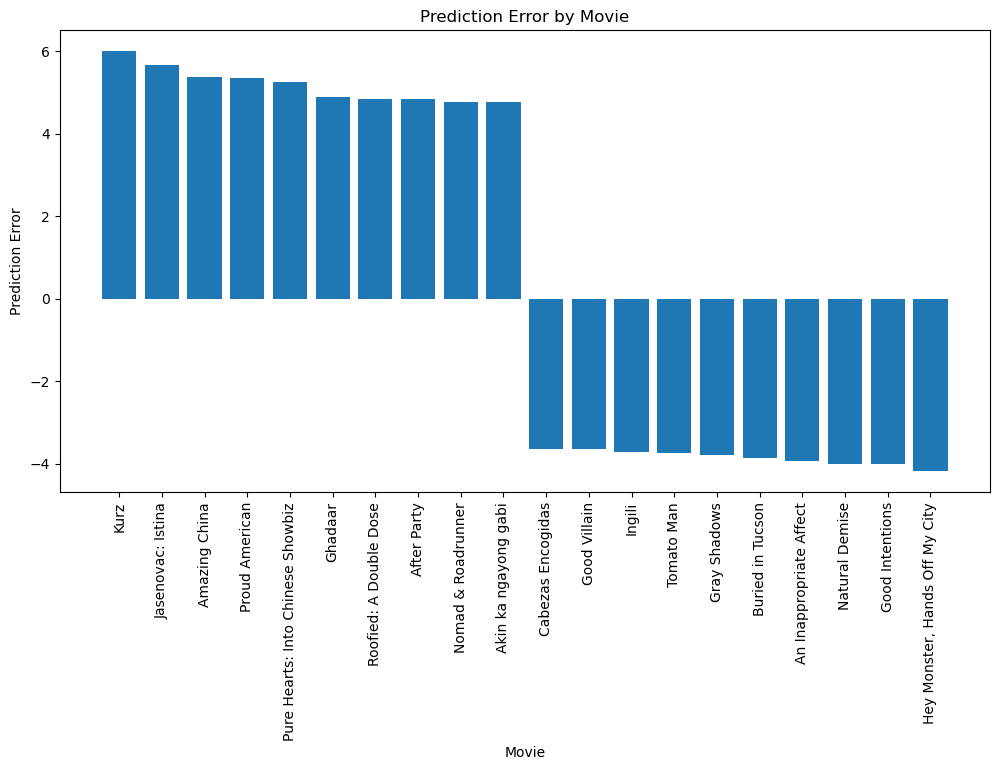

In [104]:
df_sorted = df_outliers_full_data.sort_values(
    "Prediction Error",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    df_sorted["primaryTitle"],
    df_sorted["Prediction Error"]
)

plt.xticks(rotation=90)

plt.xlabel("Movie")
plt.ylabel("Prediction Error")
plt.title("Prediction Error by Movie")

plt.show()

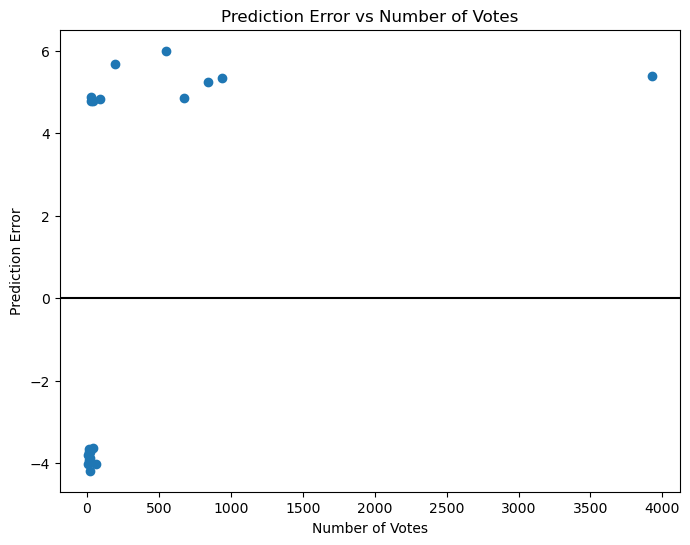

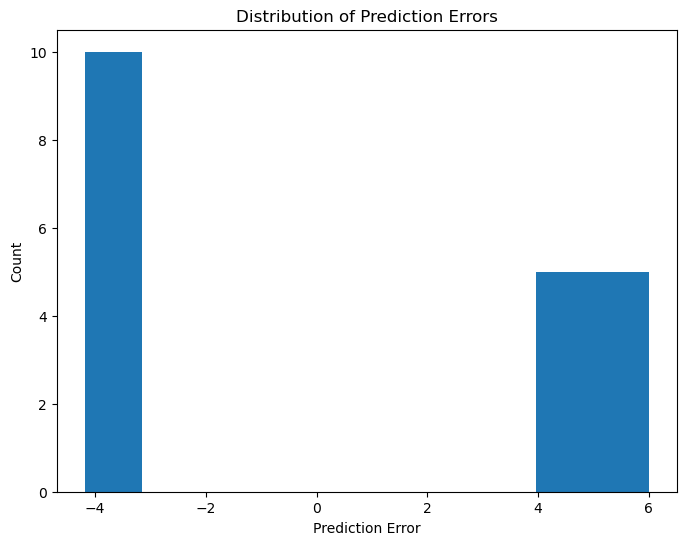

In [105]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_outliers_full_data["numVotes"],
    df_outliers_full_data["Prediction Error"]
)

plt.axhline(0, color='black')

plt.xlabel("Number of Votes")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Number of Votes")

plt.show()


plt.figure(figsize=(8,6))

plt.hist(
    df_outliers_full_data["Prediction Error"],
    bins=10
)

plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")

plt.show()

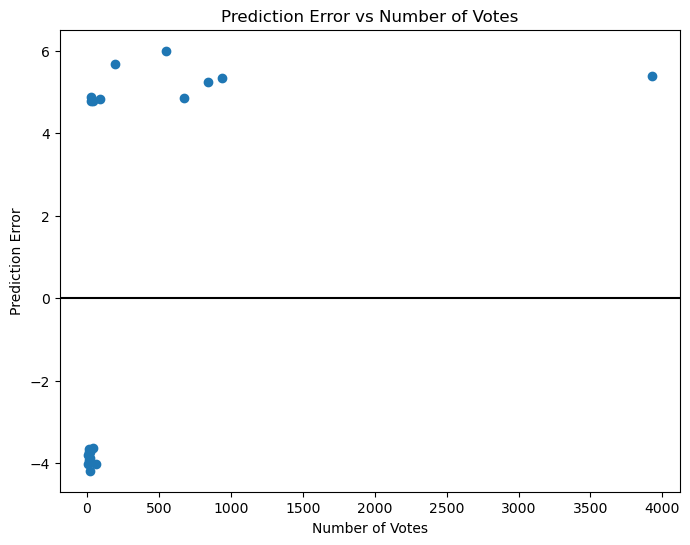

In [106]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_outliers_full_data["numVotes"],
    df_outliers_full_data["Prediction Error"]
)

plt.axhline(0, color='black')

plt.xlabel("Number of Votes")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Number of Votes")

plt.show()

The graph shows that there is no strong linear relationship between the number of votes and the prediction error.
However, many of the outlier movies have relatively low numbers of votes, suggesting that movies with smaller audiences may produce less stable ratings and are therefore harder for the model to predict accurately.

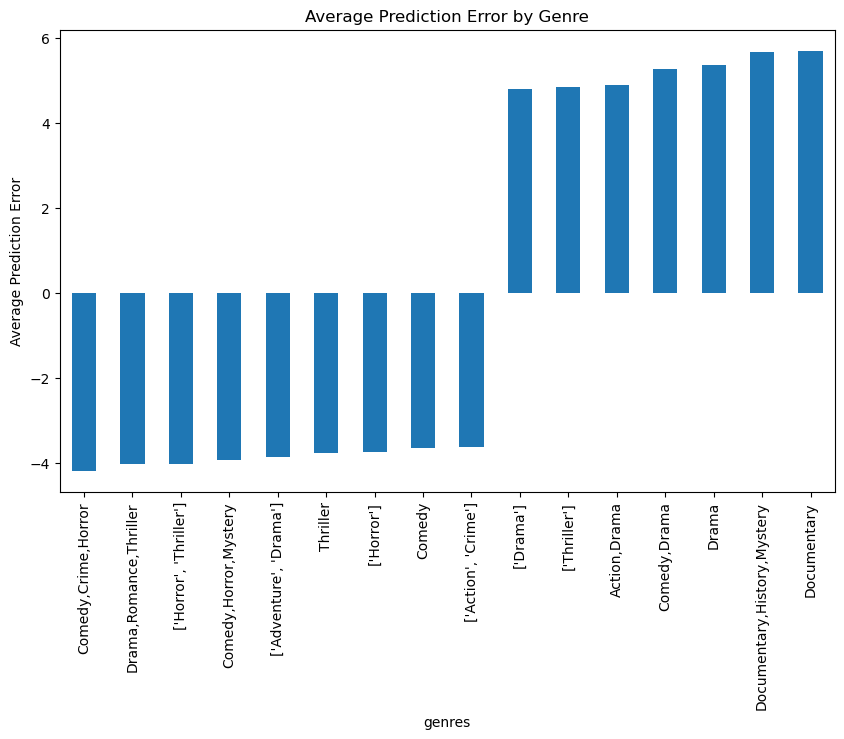

In [108]:
genre_error = (
    df_outliers_full_data
    .groupby("genres")["Prediction Error"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

genre_error.plot(kind="bar")

plt.ylabel("Average Prediction Error")
plt.title("Average Prediction Error by Genre")

plt.show()

The graph shows that prediction errors vary across movie genres, suggesting that the model performs differently depending on the type of film.
In particular, Documentary and Drama movies tend to have positive prediction errors (underpredictions), while Thriller, Horror, and Crime movies are more associated with negative prediction errors (overpredictions).

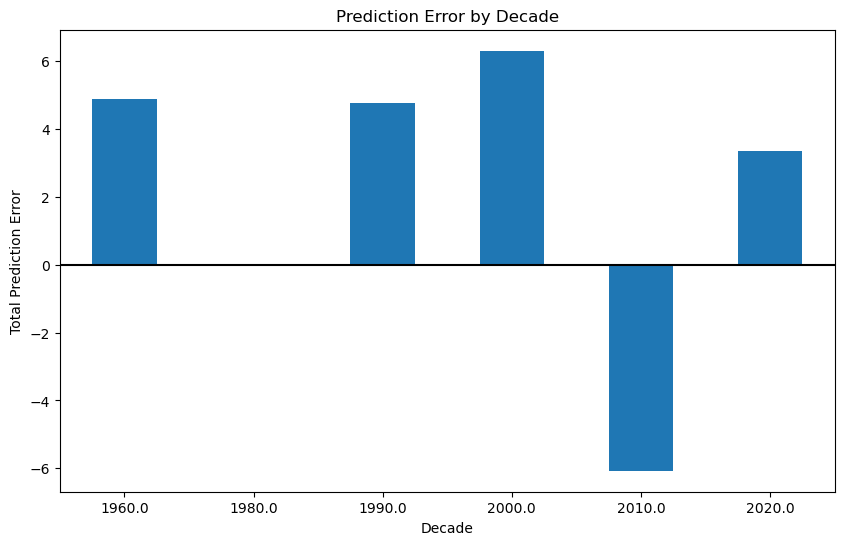

In [110]:
decade_error = (
    df_outliers_full_data
    .groupby("decade")["Prediction Error"]
    .sum()
)

plt.figure(figsize=(10,6))

decade_error.plot(kind="bar")

plt.axhline(0, color='black')

plt.xlabel("Decade")
plt.ylabel("Total Prediction Error")
plt.title("Prediction Error by Decade")

plt.xticks(rotation=0)

plt.show()

The graph suggests that prediction errors may vary across decades, indicating that the model performs differently on movies from different time periods.
In particular, movies from the 2010s tend to have negative prediction errors (overpredictions), while movies from the 1990s and 2000s show more positive errors (underpredictions).

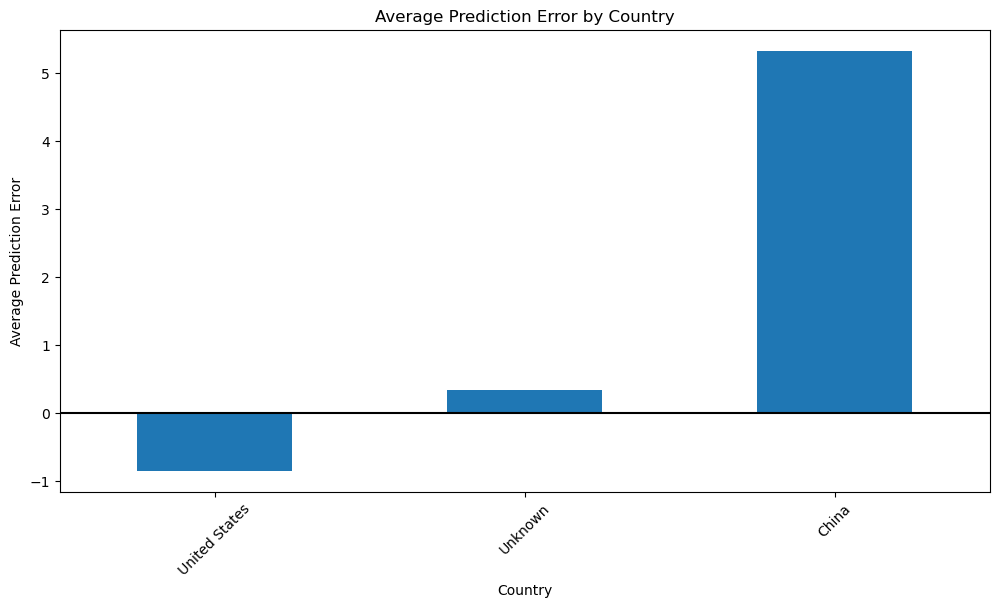

In [112]:
country_error = (
    df_outliers_full_data
    .groupby("Country")["Prediction Error"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

country_error.plot(kind="bar")


plt.axhline(0, color='black', linewidth=1.5)

plt.xlabel("Country")
plt.ylabel("Average Prediction Error")
plt.title("Average Prediction Error by Country")

plt.xticks(rotation=45)

plt.show()

The graph shows that prediction errors vary across countries, suggesting that the model performs differently depending on the movie’s country of origin.
Movies from the United States tend to have negative prediction errors, meaning the model often overpredicted their ratings.
In contrast, movies from China show strong positive prediction errors, indicating that the model underestimated their actual ratings.

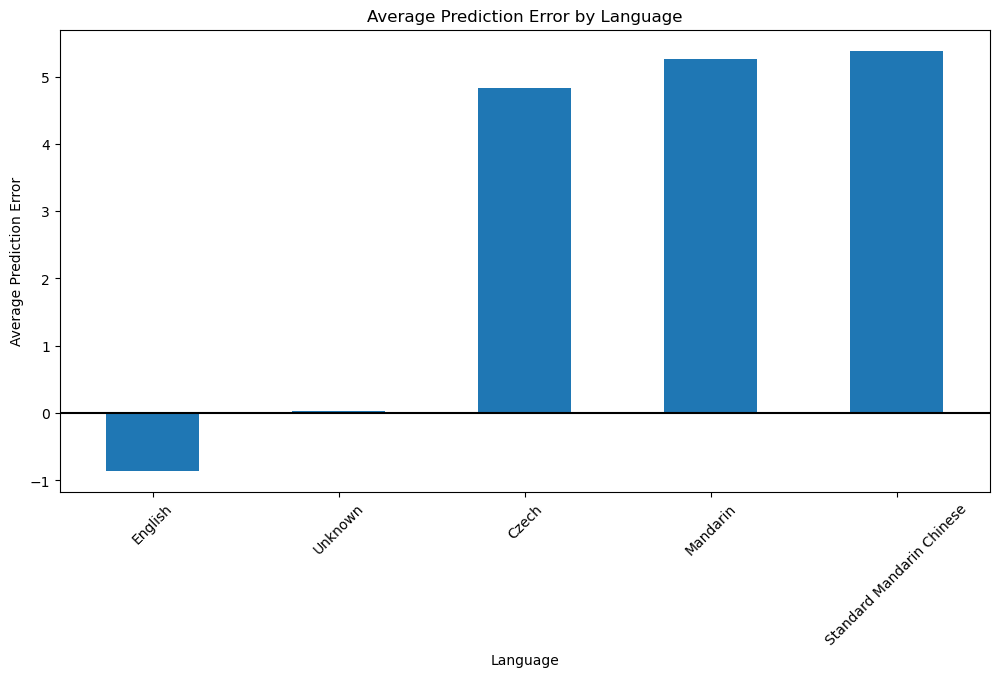

In [114]:
language_error = (
    df_outliers_full_data
    .groupby("Language")["Prediction Error"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

language_error.plot(kind="bar")


plt.axhline(0, color='black', linewidth=1.5)

plt.xlabel("Language")
plt.ylabel("Average Prediction Error")
plt.title("Average Prediction Error by Language")

plt.xticks(rotation=45)

plt.show()

The graph shows that prediction errors vary across languages, suggesting that the model performs differently depending on the movie’s language.
Movies in English tend to have negative prediction errors, meaning the model often overpredicted their ratings.
In contrast, movies in languages such as Mandarin, Standard Mandarin Chinese, and Czech show strong positive prediction errors, indicating that the model underestimated their actual ratings.

### Summary:
The analysis of the outlier movies revealed several interesting patterns in the model’s behavior, while also showing areas where no strong or clear relationships were found. Overall, the prediction errors do not appear to be completely random, but rather tend to cluster around certain groups of movies.

Regarding genres, relatively clear patterns were identified. Documentary and Drama movies tended to have more positive prediction errors, meaning the model underestimated their ratings. In contrast, Thriller, Horror, and Crime movies were more associated with negative prediction errors, meaning the model overestimated their ratings. This finding suggests that the model struggles to accurately capture the rating characteristics of certain genres.

Some differences were also observed across decades. Movies from the 2010s tended to produce more negative prediction errors (overpredictions), while movies from the 1990s and 2000s showed more positive prediction errors (underpredictions). However, due to the relatively small number of outliers, these findings should be interpreted cautiously rather than as strong statistical conclusions.

Interesting patterns were also found when analyzing movies by country. Movies from the United States tended to have negative prediction errors, meaning the model often predicted ratings that were too high. In contrast, movies from China showed particularly strong positive prediction errors, suggesting that the model struggled to accurately evaluate movies from countries that may be underrepresented in the dataset. This may indicate that the model learned patterns primarily from American movies and therefore had difficulty generalizing to other countries.

A similar trend appeared in the language analysis. Movies in English tended to produce more overpredictions, while movies in languages such as Mandarin, Standard Mandarin Chinese, and Czech were more associated with underpredictions. This may suggest a certain bias in the model toward English-language movies, likely because they are more heavily represented in the dataset.

On the other hand, when examining the relationship between the number of votes (numVotes) and the prediction error, no strong linear relationship was found. In other words, it could not be concluded that higher or lower numbers of votes directly lead to larger or smaller prediction errors. Nevertheless, many of the outlier movies had relatively low numbers of votes, which may indicate that movies with smaller audiences produce less stable ratings and are therefore more difficult for the model to predict accurately.

Overall, the model appears to exhibit recognizable error patterns across genres, languages, countries, and to some extent decades. However, no clear relationship was found between audience size (numVotes) and prediction error. In addition, because the analysis is based on a relatively small number of outlier movies, the findings should be viewed as indications of possible trends rather than definitive statistical evidence.

In [117]:
# 5.3

In [119]:
df_outliers_rd = df_outliers_full_data

In [230]:
df_outliers_rd .head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,...,is_genre_crime,is_genre_thriller,is_genre_horror,is_genre_adventure,is_genre_mystery,is_genre_family,is_genre_fantasy,is_genre_other,runtime_category,Prediction Error
5381,tt2425470,Ingili,2013.0,Thriller,"['nm3096199', 'nm3095844']",85.0,8.7,Unknown,Unknown,15.0,...,0.0,2010.0,0.0,0.0,0.0,0.0,0.0,0.0,Standard,-3.720503
10554,tt5355524,Jasenovac: Istina,2016.0,"Documentary,History,Mystery","['nm0221620', 'nm0547502']",61.0,1.4,Unknown,Unknown,192.0,...,0.0,0.0,0.0,0.0,2010.0,0.0,0.0,0.0,Standard,5.672613
16815,tt28870073,Kurz,2023.0,Documentary,[],88.0,1.2,Unknown,Unknown,547.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Standard,6.000055
28622,tt30768663,Nomad & Roadrunner,2021.0,['Drama'],"['nm15675916', 'nm13403952', 'nm15675915', 'nm...",143.0,1.9,Unknown,Unknown,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Long,4.781262
33879,tt1612610,Natural Demise,2010.0,"['Horror', 'Thriller']","['nm3826517', 'nm3987386', 'nm3827004', 'nm167...",90.0,8.5,Unknown,Unknown,60.0,...,0.0,2010.0,2010.0,0.0,0.0,0.0,0.0,0.0,Standard,-4.011002


In [121]:
df_outliers_elastic_net.head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,...,is_genre_adventure,is_genre_mystery,is_genre_family,is_genre_fantasy,is_genre_other,runtime_category,actual_rating,predicted_rating,prediction_error,outlier_type
106740,tt1053817,Buried in Tucson,2007.0,"['Adventure', 'Drama']","['nm0198119', 'nm1985743', 'nm0380142', 'nm192...",70.0,9.8,Unknown,Unknown,19.0,...,2000.0,0.0,0.0,0.0,0.0,Standard,9.8,5.839850,3.960150,Top 10 Overprediction
18469,tt6096958,Kids Against the Sorcerers,2016.0,"Adventure,Animation,Drama","['nm8469049', 'nm8152767', 'nm8469050', 'nm846...",88.0,1.1,Unknown,Unknown,582.0,...,2010.0,0.0,0.0,0.0,0.0,Standard,1.1,5.970477,-4.870477,Top 10 Underprediction
16815,tt28870073,Kurz,2023.0,Documentary,[],88.0,1.2,Unknown,Unknown,547.0,...,0.0,0.0,0.0,0.0,0.0,Standard,1.2,7.097211,-5.897211,Top 10 Underprediction
122164,tt11482408,Gray Shadows,2021.0,Thriller,"nm9358613, nm7376616, nm10597471, nm10248695, ...",110.0,9.6,Unknown,Unknown,7.0,...,0.0,0.0,0.0,0.0,0.0,Standard,9.6,5.577061,4.022939,Top 10 Overprediction
124162,tt0299926,Ggeol deok-swi,1989.0,Drama,"nm1077025, nm1077020, nm1077408",94.0,1.5,Unknown,Unknown,17.0,...,0.0,0.0,0.0,0.0,0.0,Standard,1.5,6.291678,-4.791678,Top 10 Underprediction


### Overlapping Outlier Movies

In [123]:
overlapping_tconst = (
    set(df_outliers_elastic_net['tconst']) &
    set(df_outliers_rd['tconst'])
)

print(f"Number of overlapping movies: {len(overlapping_tconst)}")

# הצגת הסרטים החופפים
overlapping_movies_df = df_outliers_elastic_net[
    df_outliers_elastic_net['tconst'].isin(overlapping_tconst)
][['tconst', 'primaryTitle']].sort_values('primaryTitle')

display(overlapping_movies_df)

Number of overlapping movies: 11


,tconst,primaryTitle
70735,tt0310595,After Party
90191,tt8081062,Amazing China
97529,tt2673726,An Inappropriate Affect
106740,tt1053817,Buried in Tucson
122164,tt11482408,Gray Shadows
130302,tt3946998,"Hey Monster, Hands Off My City"
10554,tt5355524,Jasenovac: Istina
16815,tt28870073,Kurz
33879,tt1612610,Natural Demise
48587,tt1008023,Proud American


A comparison between the Elastic Net and Random Forest outlier sets revealed that 11 movies were identified as outliers by both models. This overlap suggests that these movies represent particularly challenging cases to predict, regardless of the modeling approach used.

In [128]:
# פונקציה כללית שתזור להציג את הגרפים לפי כל שדה שנבחר

In [236]:
def plot_outliers_by_feature(df_el, df_random_forest, feature_name):"
    # הגדרת עיצוב נקי
    sns.set_theme(style="whitegrid")
    
    # יצירת עותקים וחישוב שגיאות במדד אחיד (Predicted - Actual)
    df1 = df_el.copy()
    df2 = df_random_forest.copy()
    
    df1['real_error'] = df1['predicted_rating'] - df1['actual_rating']
    df2['real_error'] = df2['Prediction Error']
    
    # איחוד הנתונים למבנה אחיד
    combined_data = []
    for _, row in df1.iterrows():
        combined_data.append({
            'Value': row[feature_name],
            'Model': 'Elastic Net',
            'Error': row['real_error'],
            'Type': 'Positive (Overprediction)' if row['real_error'] > 0 else 'Negative (Underprediction)'
        })
    for _, row in df2.dropna(subset=['real_error']).iterrows():
        combined_data.append({
            'Value': row[feature_name],
            'Model': 'Random Forest (RD)',
            'Error': row['real_error'],
            'Type': 'Positive (Overprediction)' if row['real_error'] > 0 else 'Negative (Underprediction)'
        })
        
    df_all = pd.DataFrame(combined_data)
    
    # חישוב ממוצעים וחלוקה לקבוצות
    df_pos = df_all[df_all['Type'] == 'Positive (Overprediction)'].groupby(['Value', 'Model'])['Error'].mean().reset_index()
    df_neg = df_all[df_all['Type'] == 'Negative (Underprediction)'].groupby(['Value', 'Model'])['Error'].mean().reset_index()
    
    # מיון אסתטי של הברים
    df_pos = df_pos.sort_values(by='Error', ascending=False)
    df_neg = df_neg.sort_values(by='Error', ascending=True)
    
    # יצירת הלוח (1 שורה, 2 עמודות)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- גרף שמאל: שגיאות חיוביות (Overprediction) ---
    if not df_pos.empty:
        sns.barplot(data=df_pos, x='Value', y='Error', hue='Model', palette='Oranges_r', ax=ax1)
        ax1.set_ylim(0, 6.5)
    ax1.set_title(f'Average Positive Errors (Overprediction) by {feature_name}\n[Predicted > Actual]', fontsize=12, fontweight='bold', pad=10)
    ax1.set_xlabel(feature_name, fontsize=10)
    ax1.set_ylabel('Mean Error (Predicted - Actual)', fontsize=10)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
    ax1.legend(title='Model', loc='upper right')
    
    # --- גרף ימין: שגיאות שליליות (Underprediction) ---
    if not df_neg.empty:
        sns.barplot(data=df_neg, x='Value', y='Error', hue='Model', palette='Blues_r', ax=ax2)
        ax2.set_ylim(-5.5, 0)
    ax2.set_title(f'Average Negative Errors (Underprediction) by {feature_name}\n[Predicted < Actual]', fontsize=12, fontweight='bold', pad=10)
    ax2.set_xlabel(feature_name, fontsize=10)
    ax2.set_ylabel('Mean Error (Predicted - Actual)', fontsize=10)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
    ax2.legend(title='Model', loc='lower right')
    
    plt.tight_layout()
    plt.show()

In [243]:
# ניתוח מדינה

C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')


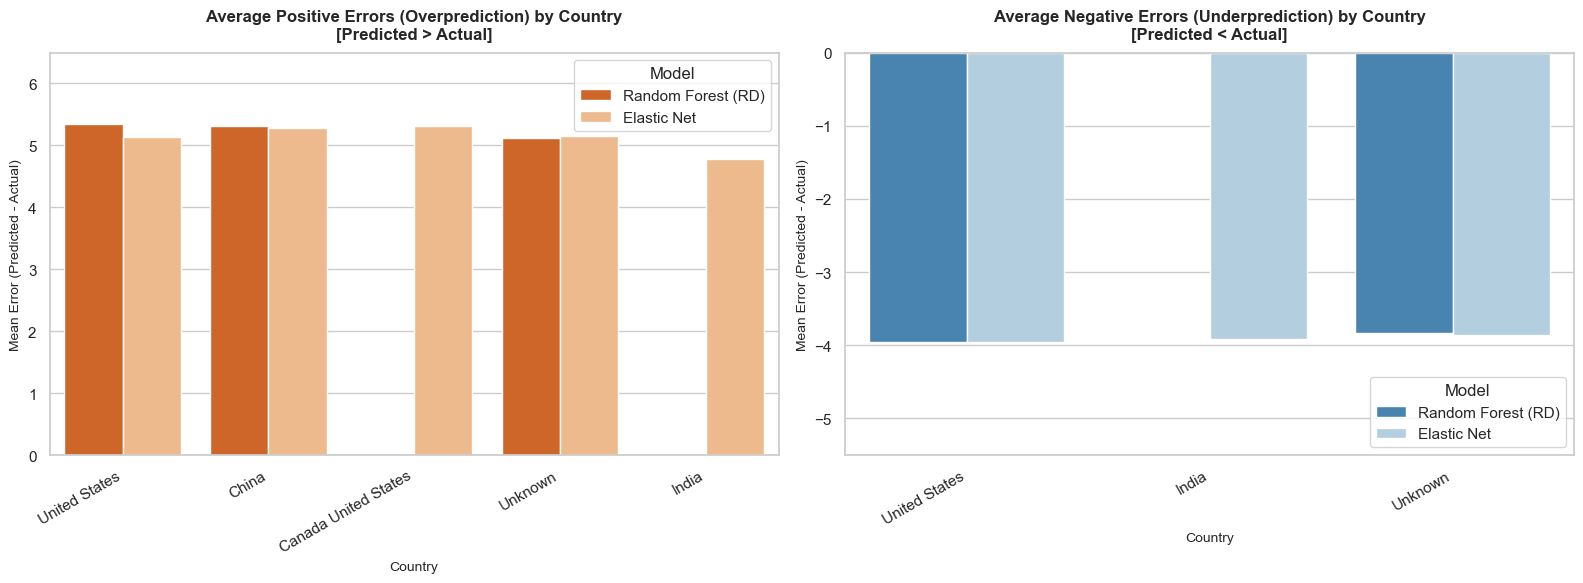

In [238]:
plot_outliers_by_feature(df_outliers_elastic_net, df_outliers_rd, 'Country')

Both models exhibit very similar error patterns across most countries, suggesting that when one model struggles, the other typically faces difficulties with the same cases as well. However, Random Forest appears in fewer countries with extreme errors than Elastic Net, indicating slightly better robustness when handling outlier cases.

In [ ]:
# ניתוח לפי שפה

C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')


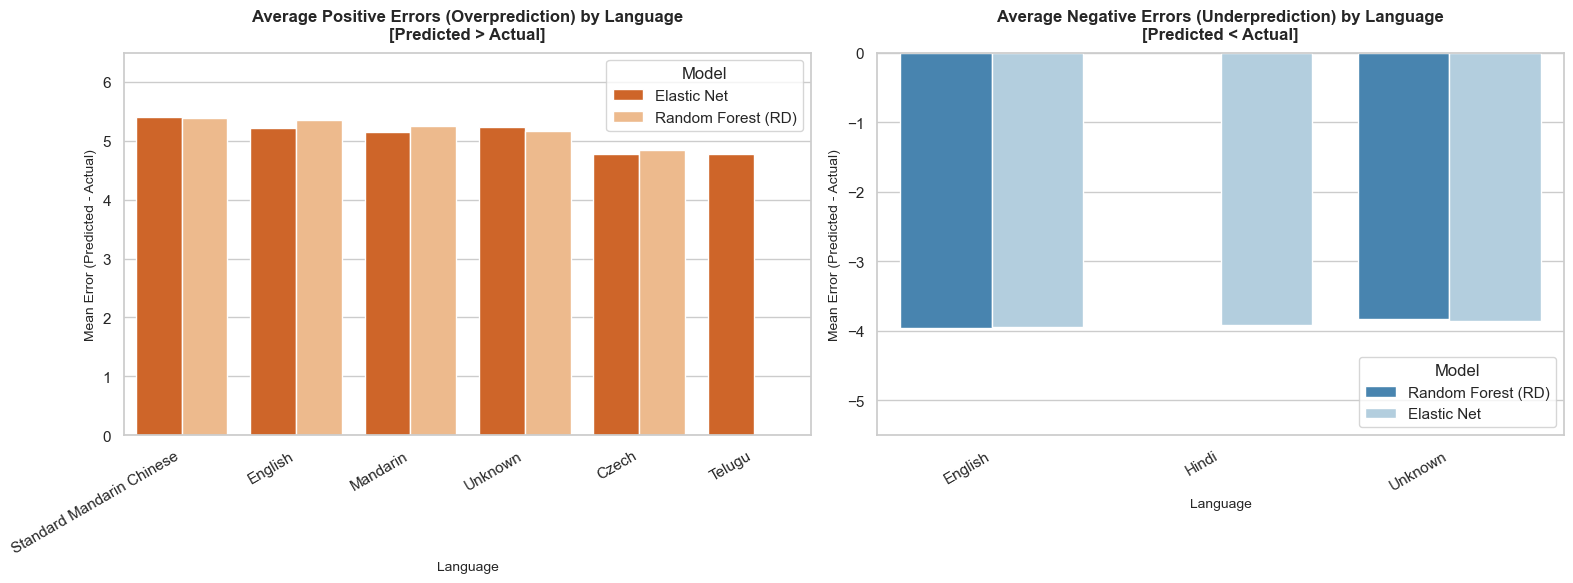

In [245]:
plot_outliers_by_feature(df_outliers_elastic_net, df_outliers_rd, 'Language')

Both models exhibit very similar error patterns across languages, suggesting that when one model struggles with a particular language group, the other tends to struggle as well. While Elastic Net and Random Forest each show a few unique language-specific outliers, neither model demonstrates a consistent advantage across languages.

In [ ]:
# ניתוח לפי קטגורית זמן

C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')


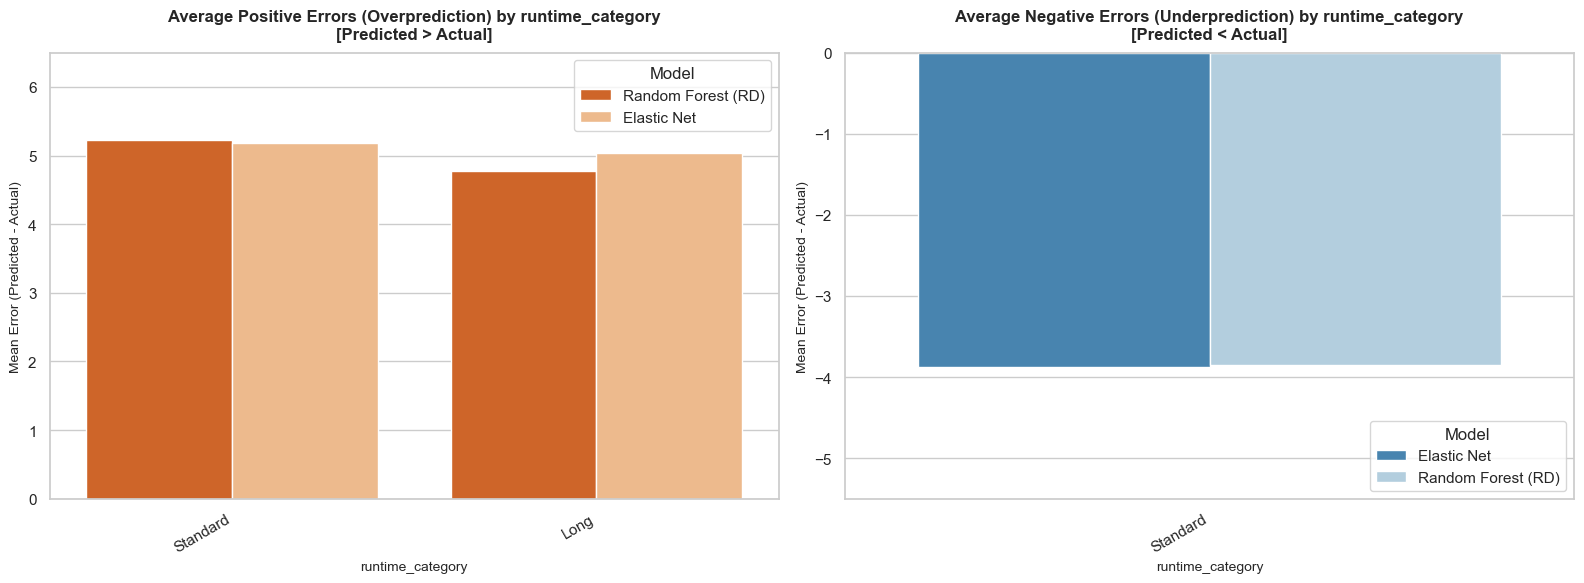

In [248]:
plot_outliers_by_feature(df_outliers_elastic_net, df_outliers_rd, 'runtime_category')

Both models show nearly identical error patterns across runtime categories, with very similar overprediction and underprediction magnitudes for both standard and long movies. This suggests that movie runtime has little impact on the relative performance of the models, as neither model demonstrates a consistent advantage across runtime categories.

In [ ]:
# ניתוח לפי מספר ג'אנרים

C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')


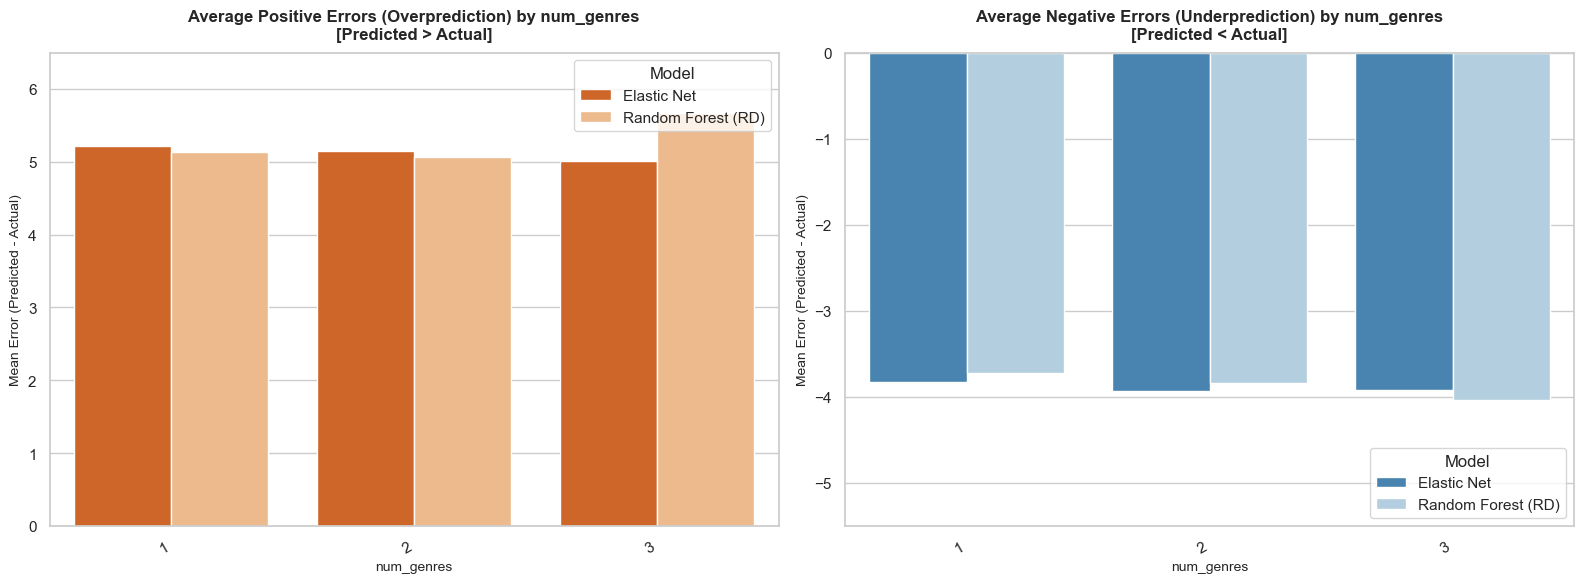

In [253]:
plot_outliers_by_feature(df_outliers_elastic_net, df_outliers_rd, 'num_genres')

Both models show very similar error patterns across different numbers of genres, indicating that genre count does not strongly influence model performance. While Random Forest exhibits slightly larger errors for movies with three genres, the overall differences between the models remain small and inconsistent.

In [256]:
# ניתוח לפי עשור

C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')


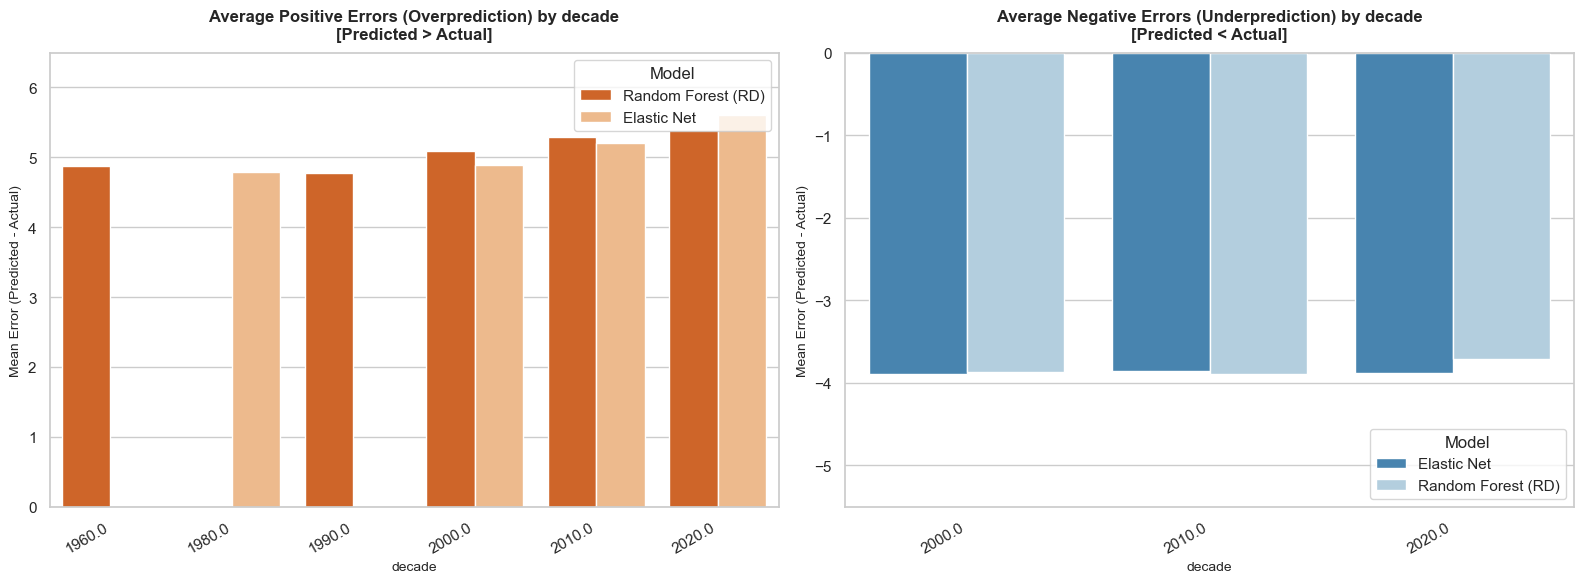

In [258]:
plot_outliers_by_feature(df_outliers_elastic_net, df_outliers_rd, 'decade')

In the decades where both models appear, the error magnitudes are very similar, indicating no clear performance advantage for either model. However, some decades appear as outliers in only one model, suggesting that each model struggles with different subsets of movies across different time periods.

In [261]:
# ניתוח לפי מספר שחקנים

C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_18584\2501029723.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')


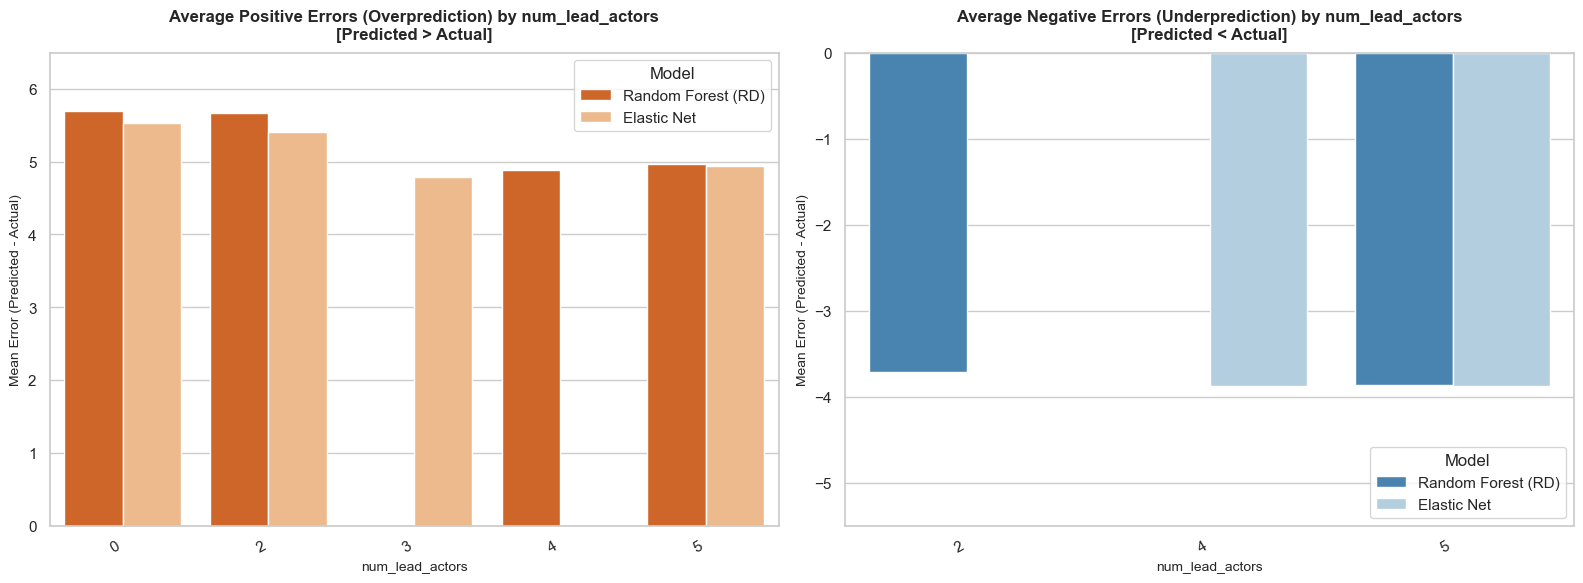

In [263]:
plot_outliers_by_feature(df_outliers_elastic_net, df_outliers_rd, 'num_lead_actors')

Both models show similar error magnitudes when they overlap, particularly for movies with 2 and 5 lead actors. However, some lead-actor categories appear as outliers in only one model (e.g., 3 lead actors for Elastic Net and 4 lead actors for Random Forest), suggesting that each model struggles with different lead-actor count configurations.

### Summary


As part of the analysis, the cases in which the **Elastic Net** and **Random Forest** models produced their largest prediction errors were examined across several characteristics: **country, language, decade, number of genres, number of lead actors, and runtime category**.

Overall, the results show that **when one model struggles, the other model generally does not perform significantly better**. In most categories where both models appeared together (countries, languages, number of genres, runtime categories, and number of lead actors), the average error magnitudes were very similar. This finding suggests that the source of the errors is not primarily related to the choice of model, but rather to limitations in the available features, missing information, or inherent characteristics of the movies that are difficult to capture using the available data.

#### Model-Specific Error Patterns

Several model-specific error patterns were identified. In multiple analyses, certain categories appeared as outliers for only one of the models. For example:

- In the **country analysis**, Elastic Net showed outliers in countries such as **Canada** and **India** that did not appear for Random Forest.
- In the **language analysis**, Elastic Net showed outliers for **Telugu**, while Random Forest showed outliers for **Hindi**.
- In the **decade analysis**, some decades appeared as outliers in only one of the models.
- In the **lead actor analysis**, Elastic Net struggled more with movies containing **3 lead actors**, while Random Forest struggled more with movies containing **4 lead actors**.

These findings indicate that although the overall performance of the models is similar, each model identifies different subsets of movies as difficult-to-predict cases. This is expected, since Elastic Net is a linear model that captures linear relationships between variables, whereas Random Forest is a non-linear model capable of identifying more complex interactions among features.

##### Features With Minimal Impact

The analyses of **runtime categories** and **genre counts** revealed almost no meaningful differences between the models. In both cases, the error patterns were nearly identical, suggesting that these features are not major contributors to performance differences between the models.

#### Overall Conclusion

The analysis suggests that **there is no category in which one model consistently succeeds while the other fails**. When extreme prediction errors occur, they tend to appear in both models and with similar magnitudes. However, each model exhibits a small number of unique error patterns, indicating different sensitivities to specific subsets of movies.

Overall, **Random Forest appears slightly more robust**, as it produced fewer unique outlier groups in several categories, although the advantage is not substantial. Therefore, the primary source of extreme prediction errors is likely the limitations of the available features rather than the choice of predictive model itself.

In [ ]:
5.4

### Feature 1: Historical Actor Appearance Count

This feature represents the average number of previous movie appearances of the lead actors up to the movie's release year. It enables the model to distinguish between movies featuring experienced, well-established actors and movies featuring relatively new or less recognized actors, even when other characteristics such as country, language, genre, and runtime are very similar.

This feature could help reduce the outlier errors identified in the analysis because the current model only captures the number of lead actors, but does not account for their experience, career history, or industry presence. Movies starring highly experienced actors may receive different ratings than movies with otherwise similar characteristics but featuring unknown actors. By incorporating this information, the model would gain a stronger indication of the expected quality and audience reception of a movie, potentially improving prediction accuracy in cases where the existing features are not sufficiently informative.

### Feature 2: Genre Popularity Score

This feature represents the average historical number of votes (numVotes) for a movie’s genres up to the movie’s release year. To avoid data leakage, the calculation would be based only on movies released before the target movie’s release year. For movies belonging to multiple genres, the feature would be calculated as the average historical vote count across all associated genres.

This feature could help reduce the outlier errors identified in the analysis because the current model knows which genres are associated with a movie, but it does not capture how popular those genres have historically been among audiences. Some genres consistently attract larger audiences and receive greater attention, while others appeal to smaller niche groups. By incorporating this information, the model can better estimate the expected audience interest in a movie and distinguish between films with otherwise similar characteristics, potentially reducing extreme prediction errors.

### Feature 3: Director Experience Count

This feature represents the number of movies directed by the movie’s director prior to the movie’s release year. To avoid data leakage, the calculation would be based only on movies released before the target movie. The required information could be obtained from the IMDb datasets by linking each movie to its director and counting the director’s previous directing credits.

This feature could help reduce the outlier errors identified in the analysis because the current model does not include any information about the director, despite the director often having a significant influence on a movie’s quality and audience reception. As a result, the model may treat two movies with similar characteristics (e.g., genre, language, country, and runtime) as equally likely to receive similar ratings, even when one is directed by a highly experienced director and the other by a first-time director.

By incorporating director experience, the model would gain additional information about the likelihood of a movie meeting audience expectations. This could help explain some of the extreme overpredictions and underpredictions observed in the outlier analysis, where the existing features were not sufficient to distinguish between movies with similar observable characteristics but different levels of directing expertise.

In [ ]:
# סעיף 6

In [294]:
# 1. הכנת הנתונים
fairness_df = df_test_prepared_rf.copy()
fairness_df['Actual'] = y_test_rf
fairness_df['Predicted'] = y_pred_rf

# 2. ריכוז המדדים בלולאה
decade_rows = []
for decade, group in fairness_df[fairness_df['decade'] > 0].groupby('decade'):
    if len(group) >= 5:
        rmse = np.sqrt(mean_squared_error(group['Actual'], group['Predicted']))
        mae = mean_absolute_error(group['Actual'], group['Predicted'])
        
        decade_rows.append({
            'Decade': f"{int(decade)}s",
            'Movies Number': len(group),
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4)
        })

# 3. יצירת ה-DataFrame והצגתו כטבלה מעוצבת
df_decades_table = pd.DataFrame(decade_rows)
df_decades_table

,Decade,Movies Number,RMSE,MAE
0,1910s,31,0.7205,0.5701
1,1920s,160,1.0549,0.7602
2,1930s,655,0.8054,0.6080
3,1940s,673,0.7799,0.5838
4,1950s,951,0.9011,0.6890
5,1960s,1283,1.0247,0.7992
6,1970s,1554,1.0073,0.7941
7,1980s,1932,1.0655,0.8333
8,1990s,2051,1.0613,0.8287
9,2000s,3485,1.1498,0.8798


##### It can be observed that the prediction error tends to increase in more recent decades.

##### Movie ratings in earlier decades were heavily influenced by historical rating patterns. During the 1930s and 1940s, ratings were generally more accurate because fewer movies were produced and only a small number of elite films received significant attention and ratings from critics and audiences.

##### In contrast, from the 1980s onward, the film industry expanded considerably in terms of genres, production investments, and target audiences. This led to a much larger number of rated movies and greater variation in ratings, as the volume of audience and critic reviews increased substantially compared to earlier decades.

In [299]:
top_5_genres = trained_top_lists['genres'][:5]


genre_rows = []
for genre in top_5_genres:
    genre_col = f"is_genre_{genre.replace('-', '_').replace(' ', '_')}"
    
    if genre_col in fairness_df.columns:
        group = fairness_df[fairness_df[genre_col] > 0]
        if len(group) > 0:
            rmse = np.sqrt(mean_squared_error(group['Actual'], group['Predicted']))
            mae = mean_absolute_error(group['Actual'], group['Predicted'])
            
            genre_rows.append({
                'Genre': genre.capitalize(),
                'Movies Number': len(group),
                'RMSE': round(rmse, 4),
                'MAE': round(mae, 4)
            })


df_genres_table = pd.DataFrame(genre_rows)
df_genres_table

,Genre,Movies Number,RMSE,MAE
0,Drama,11715,1.0468,0.7990
1,Comedy,6672,1.1250,0.8633
2,Romance,3206,1.0211,0.7782
3,Action,2708,1.1901,0.9280
4,Documentary,2637,0.9656,0.7165


##### It can also be observed that there are noticeable differences among the five main genres identified. Documentary movies tend to have relatively lower prediction errors, while Action movies exhibit comparatively higher prediction errors.

##### One possible explanation is that documentary films are typically aimed at a more specific audience that has clearer expectations regarding the content and quality of the movie. In contrast, Action and Comedy movies target a much broader audience, whose opinions and preferences may vary considerably.

##### As a result, ratings for Action and Comedy movies tend to be more diverse and less predictable, leading to larger prediction errors compared to Documentary films.

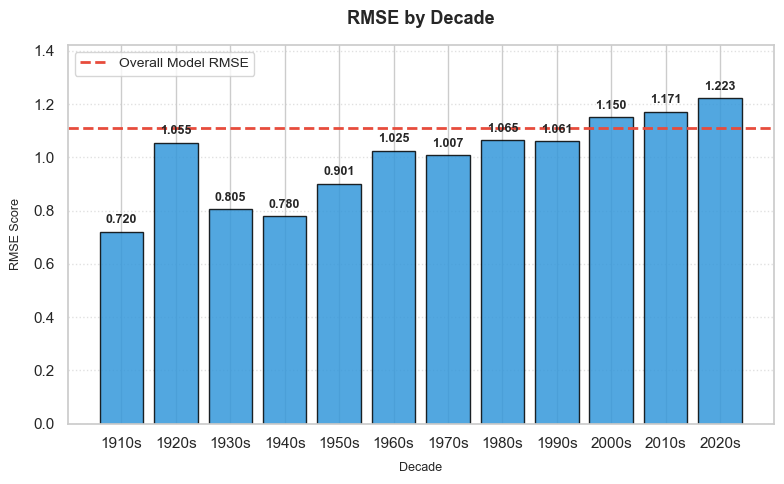

In [304]:
fairness_df = df_test_prepared_rf.copy()
fairness_df['Actual'] = y_test_rf
fairness_df['Predicted'] = y_pred_rf


decade_metrics = []
for decade, group in fairness_df[fairness_df['decade'] > 0].groupby('decade'):
    if len(group) >= 5:  # סינון עשורים ללא ייצוג מספק
        rmse = np.sqrt(mean_squared_error(group['Actual'], group['Predicted']))
        decade_metrics.append({
            'Decade': f"{int(decade)}s",
            'RMSE': rmse
        })

df_decades_dynamic = pd.DataFrame(decade_metrics)


baseline_rmse = np.sqrt(mean_squared_error(fairness_df['Actual'], fairness_df['Predicted']))


fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_decades_dynamic['Decade'], df_decades_dynamic['RMSE'], color='#3498db', edgecolor='black', alpha=0.85)
ax.axhline(baseline_rmse, color='#e74c3c', linestyle='--', linewidth=2, label=f'Overall Model RMSE')


ax.set_title('RMSE by Decade', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Decade', fontsize=9, labelpad=8)
ax.set_ylabel('RMSE Score', fontsize=9, labelpad=8)
ax.set_ylim(0, max(df_decades_dynamic['RMSE']) + 0.2)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.6)


for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()

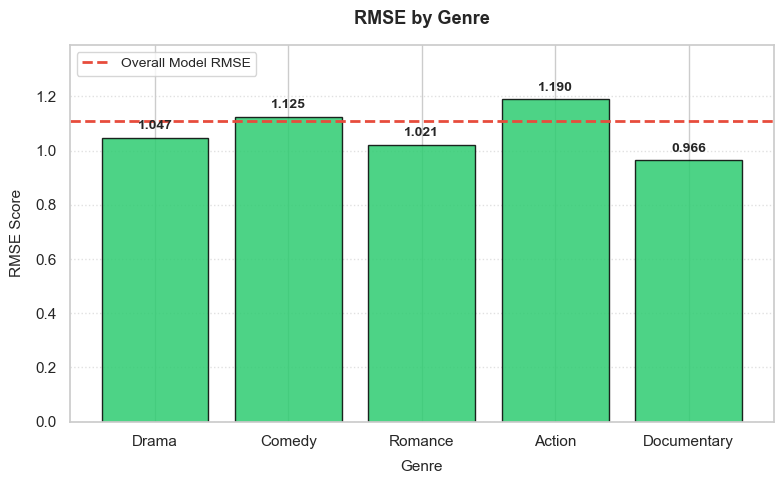

In [307]:
top_5_genres = trained_top_lists['genres'][:5]


genre_metrics = []
for genre in top_5_genres:
   
    genre_col = f"is_genre_{genre.replace('-', '_').replace(' ', '_')}"
    
    if genre_col in fairness_df.columns:
        group = fairness_df[fairness_df[genre_col] > 0]
        if len(group) > 0:
            rmse = np.sqrt(mean_squared_error(group['Actual'], group['Predicted']))
            genre_metrics.append({
                'Genre': genre.capitalize(),
                'RMSE': rmse
            })

df_genres_dynamic = pd.DataFrame(genre_metrics)


baseline_rmse = np.sqrt(mean_squared_error(fairness_df['Actual'], fairness_df['Predicted']))


fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_genres_dynamic['Genre'], df_genres_dynamic['RMSE'], color='#2ecc71', edgecolor='black', alpha=0.85)
ax.axhline(baseline_rmse, color='#e74c3c', linestyle='--', linewidth=2, label=f'Overall Model RMSE')


ax.set_title('RMSE by Genre', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Genre', fontsize=11, labelpad=8)
ax.set_ylabel('RMSE Score', fontsize=11, labelpad=8)
ax.set_ylim(0, max(df_genres_dynamic['RMSE']) + 0.2)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.6)


for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

In [313]:
fairness_df = df_test_prepared_rf.copy()
fairness_df['Actual'] = y_test_rf
fairness_df['Predicted'] = y_pred_rf


decade_table_data = []
for decade, group in fairness_df[fairness_df['decade'] > 0].groupby('decade'):
    if len(group) >= 5:
        rmse = np.sqrt(mean_squared_error(group['Actual'], group['Predicted']))
        mae = mean_absolute_error(group['Actual'], group['Predicted'])
        decade_table_data.append({
            'decade': f"{int(decade)}s",
            'Movie count': len(group),
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4)
        })


df_decades_table = pd.DataFrame(decade_table_data)
print("--- RMSE and MAE by Decade ---")
display(df_decades_table)

--- RMSE and MAE by Decade ---


,decade,Movie count,RMSE,MAE
0,1910s,31,0.7205,0.5701
1,1920s,160,1.0549,0.7602
2,1930s,655,0.8054,0.6080
3,1940s,673,0.7799,0.5838
4,1950s,951,0.9011,0.6890
5,1960s,1283,1.0247,0.7992
6,1970s,1554,1.0073,0.7941
7,1980s,1932,1.0655,0.8333
8,1990s,2051,1.0613,0.8287
9,2000s,3485,1.1498,0.8798


In [319]:
# חלק 7

In [316]:
# 1. Extract the automatic feature names from the model's Preprocessor step
# (The feature names are identical for both models because they received the same X_train columns)
feature_names = grid_search_en.best_estimator_['preprocessor'].get_feature_names_out()

# Light cleaning of feature names to keep them readable (remove num__ and cat__ prefixes)
clean_feature_names = [name.split('__')[-1] for name in feature_names]

# =========================================================================
# Part A: Extract the Top 5 Features for Elastic Net (based on coefficients)
# =========================================================================
en_coefs = grid_search_en.best_estimator_['regressor'].coef_

df_en_importance = pd.DataFrame({
    'Feature': clean_feature_names,
    'Coefficient': en_coefs,
    'Absolute_Coef': np.abs(en_coefs)
})

# Sort by absolute value (feature importance regardless of direction) and extract the top 5
df_en_top5 = df_en_importance.sort_values(by='Absolute_Coef', ascending=False).head(5).copy()

# Determine the direction of the effect (positive/negative)
df_en_top5['Direction'] = df_en_top5['Coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

print("=" * 60)
print("Top 5 Most Important Features - Elastic Net")
print("=" * 60)
display(df_en_top5[['Feature', 'Coefficient', 'Direction']])


# =========================================================================
# Part B: Extract the Top 5 Features for Random Forest (based on Feature Importance)
# =========================================================================
rf_importances = grid_search_rf.best_estimator_['regressor'].feature_importances_

df_rf_importance = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': rf_importances
})

# Sort and extract the top 5 features from the tree-based model
df_rf_top5 = df_rf_importance.sort_values(by='Importance', ascending=False).head(5).copy()

# In tree-based models (Random Forest), feature importance only indicates importance
# (a positive value between 0 and 1) and does not indicate direction.
# To estimate the direction of the effect, we examine the sign of the correlation
# between the feature and y_train.
directions_rf = []
for feat in df_rf_top5['Feature']:
    # If the feature is a categorical column that underwent One-Hot Encoding
    # (e.g., runtime_category), adjust the name for lookup
    orig_col = feat if feat in X_train.columns else [c for c in X_train.columns if c in feat or feat in str(X_train[c].dtype)][0]
    
    # Compute a simple correlation to estimate the direction of the effect
    corr = np.corrcoef(X_train[orig_col].astype(float), y_train)[0, 1] if orig_col in X_train.columns else 0
    directions_rf.append('Positive' if corr >= 0 else 'Negative')

df_rf_top5['Direction'] = directions_rf

print("\n" + "=" * 60)
print("Top 5 Most Important Features - Random Forest")
print("=" * 60)
display(df_rf_top5[['Feature', 'Importance', 'Direction']])

Top 5 Most Important Features - Elastic Net


,Feature,Coefficient,Direction
31,is_genre_documentary,0.378493,Positive
34,is_genre_horror,-0.230985,Negative
0,runtimeMinutes,0.215685,Positive
27,is_genre_drama,0.182080,Positive
4,decade,-0.115651,Negative



Top 5 Most Important Features - Random Forest


,Feature,Importance,Direction
31,is_genre_documentary,0.285086,Positive
34,is_genre_horror,0.204337,Negative
0,runtimeMinutes,0.181424,Positive
27,is_genre_drama,0.074058,Positive
4,decade,0.037887,Negative
